In [1]:
# imports

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

from typing import Union, Dict, List
from scipy.ndimage import label

from torch.utils.data import TensorDataset, DataLoader
import fitsio
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from typing import Union, List, Dict

from datetime import datetime

CB_color_cycle = [
    '#377eb8', '#ff7f00', '#4daf4a',
    '#f781bf', '#a65628', '#984ea3',
    '#999999', '#e41a1c', '#dede00'
]

In [2]:
def save_model_checkpoint(
    filepath: str,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer = None,
    scheduler = None,
    epoch: int = 0,
    val_loss: float = float("inf"),
    config: dict = None
):
    """
    Saves a comprehensive PyTorch model checkpoint.
    """
    checkpoint = {
        "epoch": epoch,
        "val_loss": val_loss,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "config": config or {}
    }
    torch.save(checkpoint, filepath)
    print(f"--> Saved checkpoint to '{filepath}' (Epoch {epoch+1}, Val Loss: {val_loss:.4f})")


def load_model_checkpoint(
    filepath: str,
    device: torch.device,
    model_class=None,
):
    """
    Loads a saved checkpoint and returns the model, optimizer/scheduler states, and metadata.
    """
    checkpoint = torch.load(filepath, map_location=device)
    config = checkpoint["config"]

    # Reconstruct model architecture using stored configuration
    model = model_class(
        in_channels=config.get("in_channels", 2),
        num_species=config.get("num_species", 1)
    ).to(device)

    # Load weights
    model.load_state_dict(checkpoint["model_state_dict"])
    
    print(f"--> Loaded checkpoint '{filepath}' (Trained for {checkpoint['epoch']+1} epochs, Val Loss: {checkpoint['val_loss']:.4f})")
    return model, checkpoint


In [3]:
#list of all metals 

# metal_list = [
#     "MgI(2853)", "MgII(2804)", "MgII(2796)",
#     "FeII(2600)", "FeII(2587)", "MnII(2577)",
#     "FeII(2383)", "FeII(2374)", "FeII(2344)",
#     "AlIII(1863)", "AlIII(1855)", "AlII(1671)",
#     "FeII(1608)", "CIV(1551)", "CIV(1548)",
#     "SiII(1527)", "SiIV(1403)", "SiIV(1394)",
#     "CII(1335)", "SiII(1304)", "OI(1302)",
#     "SiII(1260)", "NV(1243)", "NV(1239)",
#     "SiIII(1207)", "NI(1200)", "SiII(1193)", "SiII(1190)",
#     "OI(1039)", "OVI(1038)", "OVI(1032)",
#     "LYB", "CIII(977)", "OI(989)", "SiII(990)",
#     "LY3", "LY4", "LY5",
# ]
# strength_list = [
#     "1e-4", "5e-4", "9e-4",          # MgI MgII(2804) MgII(2796)
#     "1e-4", "1e-4", "1e-4",          # FeII(2600) FeII(2587) MnII(2577)
#     "1e-4", "1e-4", "1e-4",          # FeII(2383) FeII(2374) FeII(2344)
#     "1e-4", "1e-4", "1e-4",          # AlIII(1863) AlIII(1855) AlII(1671)
#     "1e-4", "5.435e-4", "1.487e-3",  # FeII(1608) CIV(1551) CIV(1548)
#     "1e-4", "5e-4", "9e-4",          # SiII(1527) SiIV(1403) SiIV(1394)
#     "1e-4", "1e-4", "1e-4",          # CII(1335) SiII(1304) OI(1302)
#     "4.2504e-4", "5e-4", "5e-4",     # SiII(1260)* NV(1243) NV(1239)
#     "9.4595e-4", "1e-3", "6.354e-4", "4.496e-4",  # SiIII(1207)* NI(1200) SiII(1193)* SiII(1190)*
#     "1e-3", "3.382e-3", "5.358e-3",  # OI(1039) OVI(1038) OVI(1032)
#     "0.1901", "5e-3", "1e-3", "1e-3",# LYB CIII(977) OI(989) SiII(990)
#     "0.0697", "0.0335", "0.0187",    # LY3 LY4 LY5
# ]


# # Expected format: 
# METAL_LINES_LIST = {
#     "SiII_1190": 1190.4158,
#     "SiII_1193": 1193.2897,
#     "SiIII_1207": 1206.500,
#     "SiII_1260": 1206.500,
#     "CIV_1548": 1548.2049,
#     "CIV_1550": 1550.77845,
#     'MgI(2853)': 2852.96,
# }

### Check transmission file from P1D code

Wavelength shape: (31001,)
Single flux shape: (31001,)


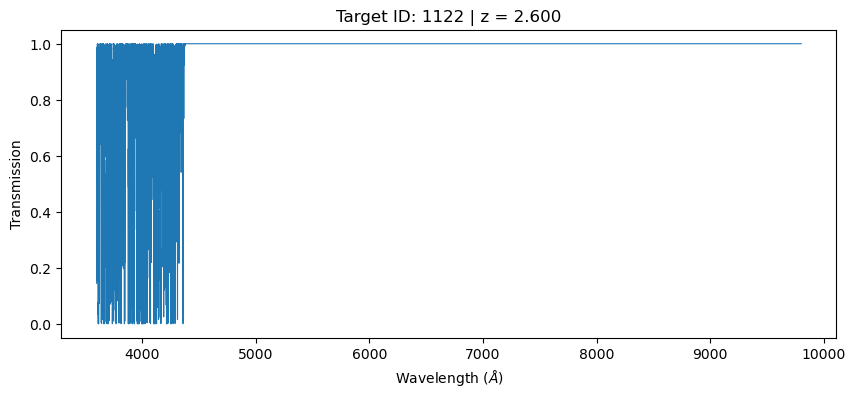

In [4]:
# load transmission file (preprocessed)
p1d_file = '/global/cfs/cdirs/desicollab/users/mherbold/p1d_mocks/DR1/QQ_output_test/transmission-16-1_2.fits'

# Read arrays
meta = fitsio.read(p1d_file, ext="METADATA")
wave = fitsio.read(p1d_file, ext="WAVELENGTH")
fluxes = fitsio.read(p1d_file, ext="TRANSMISSION")

# Pick single spectrum index
i = 100

# Extract and squeeze shape
single_flux = fluxes[i].squeeze()
target_id = meta["MOCKID"][i]
z = meta["Z"][i]

# Check shapes directly
print(f"Wavelength shape: {wave.shape}")        # Output: (31001,)
print(f"Single flux shape: {single_flux.shape}")  # Output: (31001,)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(wave, single_flux, lw=0.8)
plt.xlabel(r"Wavelength ($\AA$)")
plt.ylabel("Transmission")
plt.title(f"Target ID: {target_id} | z = {z:.3f}")
# plt.xlim(3000,5000)
plt.show()

### Generate training samples

In [5]:
def rebin_dataset_to_log_lambda(wave_grid: np.ndarray, fluxes: np.ndarray, num_log_pixels: int = None):
    """
    Interpolates a batch of flux spectra from a linear wavelength grid 
    to a strictly uniform log-wavelength grid (constant delta ln(wave)).
    """
    # Define uniform log-wavelength bounds
    log_wave_min = np.log(wave_grid[0])
    log_wave_max = np.log(wave_grid[-1])
    
    if num_log_pixels is None:
        num_log_pixels = len(wave_grid)
        
    log_wave_grid = np.linspace(log_wave_min, log_wave_max, num_log_pixels)
    linear_wave_from_log = np.exp(log_wave_grid)
    
    # Re-interpolate all spectra onto the new uniform log wavelength grid
    N_specs = fluxes.shape[0]
    fluxes_log = np.zeros((N_specs, num_log_pixels), dtype=np.float32)
    
    for idx in range(N_specs):
        fluxes_log[idx] = np.interp(linear_wave_from_log, wave_grid, fluxes[idx])
        
    return log_wave_grid, fluxes_log

In [6]:
# def generate_multimetal_dataset(
#     lya_flux_samples: np.ndarray,
#     log_wave_grid: np.ndarray,
#     metal_dict: dict,
#     lya_wave: float = 1215.67,
#     num_samples: int = 5000,
#     max_metals_per_spectrum: int = 1,
#     snr: float = 30.0,                 # noise injected into INPUT flux; None = noiseless input
#     target_snr: float = 30.0,          # SNR used for SNR-based detection thresholding
#     detect_sigma: float = 3.0,         # significance threshold
#     tau_min_fraction: float = 0.0,     # per-species or global fractional floor (relative to tau_lya)
#     tau_min_thresh = None,             # explicit threshold override
#     zero_metal_prob: float = 0.25,
#     a_min = 0.2,
#     a_max = 1.0,
# ) -> TensorDataset:
#     """
#     Generates synthetic multi-metal spectrum dataset with flexible per-species amplitudes 
#     and relative optical depth masks that do not collapse at low amplitudes.
#     """   
#     n_input, n_pixels = lya_flux_samples.shape
#     num_species = len(metal_dict)
#     species_keys = list(metal_dict.keys())
#     d_log_wave = log_wave_grid[1] - log_wave_grid[0]
    
#     pixel_shifts = {
#         key: int(np.round(np.log(w / lya_wave) / d_log_wave))
#         for key, w in metal_dict.items()
#     }

#     X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
#     Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
#     # Initialize Y_amp with a sentinel (-10.0) so unmasked background doesn't default to A=1.0 (log10=0)
#     Y_amp  = np.full((num_samples, num_species, n_pixels), -10.0, dtype=np.float32)

#     tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

#     for i in range(num_samples):
#         rand_idx = np.random.randint(0, n_input)
#         tau_lya = tau_lya_pool[rand_idx]
#         tau_total = np.copy(tau_lya)
        
#         inject_metal = (np.random.rand() > zero_metal_prob)

#         if inject_metal:
#             n_active = np.random.randint(1, max_metals_per_spectrum + 1)
#             active_species = np.random.choice(species_keys, size=n_active, replace=False)

#             for species in active_species:
#                 s_idx = species_keys.index(species)
#                 shift = pixel_shifts[species]
                
#                 # --- Resolve per-species a_min and a_max ---
#                 if isinstance(a_min, dict):
#                     sp_a_min = a_min.get(species, 0.2)
#                 elif isinstance(a_min, (list, tuple)):
#                     sp_a_min = a_min[s_idx]
#                 else:
#                     sp_a_min = float(a_min)

#                 if isinstance(a_max, dict):
#                     sp_a_max = a_max.get(species, 1.0)
#                 elif isinstance(a_max, (list, tuple)):
#                     sp_a_max = a_max[s_idx]
#                 else:
#                     sp_a_max = float(a_max)

#                 # --- Resolve per-species tau_min_fraction ---
#                 if isinstance(tau_min_fraction, dict):
#                     sp_tau_frac = tau_min_fraction.get(species, 0.05)
#                 elif isinstance(tau_min_fraction, (list, tuple)):
#                     sp_tau_frac = tau_min_fraction[s_idx]
#                 else:
#                     sp_tau_frac = float(tau_min_fraction)

#                 log_a_min, log_a_max = np.log10(sp_a_min), np.log10(sp_a_max)
#                 log10_A = np.random.uniform(log_a_min, log_a_max) if log_a_min != log_a_max else log_a_min
#                 A = 10.0 ** log10_A

#                 tau_metal = np.roll(tau_lya, shift)
#                 if shift > 0:
#                     tau_metal[:shift] = 0.0
#                 elif shift < 0:
#                     tau_metal[shift:] = 0.0
                
#                 tau_metal_effective = A * tau_metal
#                 tau_total += tau_metal_effective
                
#                 # --- Resolve optical depth mask threshold ---
#                 if tau_min_thresh is not None:
#                     if isinstance(tau_min_thresh, dict):
#                         sp_tau_thresh = tau_min_thresh.get(species, 0.05)
#                     elif isinstance(tau_min_thresh, (list, tuple)):
#                         sp_tau_thresh = tau_min_thresh[s_idx]
#                     else:
#                         sp_tau_thresh = float(tau_min_thresh)
#                     metal_active_mask = (tau_metal_effective >= sp_tau_thresh)
#                 else:
#                     # Scale threshold with relative structural tau_lya profile
#                     # or scale SNR floor relative to metal amplitude A
#                     metal_active_mask = (tau_metal >= sp_tau_frac)

#                 Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
#                 Y_amp[i, s_idx, :]  = log10_A

#         # Flux conversion & noise injection
#         flux_true = np.exp(-tau_total)
#         if snr is None or snr >= 1e5:
#             flux_obs = flux_true
#         else:
#             noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
#             flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
#         tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

#         X_data[i, 0, :] = tau_obs
#         for s_idx, species in enumerate(species_keys):
#             shift = pixel_shifts[species]
#             X_data[i, 1 + s_idx, :] = np.roll(tau_obs, shift)

#     return TensorDataset(
#         torch.from_numpy(X_data),
#         torch.from_numpy(Y_mask),
#         torch.from_numpy(Y_amp)
#     )

In [10]:
def generate_multimetal_dataset(
    lya_flux_samples: np.ndarray,
    log_wave_grid: np.ndarray,
    metal_dict: dict,
    lya_wave: float = 1215.67,
    num_samples: int = 5000,
    max_metals_per_spectrum: int = 1,
    snr: float = 30.0,
    target_snr: float = 30.0,
    detect_sigma: float = 3.0,
    tau_min_fraction: float = 0.0,
    tau_min_thresh = None,
    zero_metal_prob: float = 0.25,
    a_min = 0.2,
    a_max = 1.0,
) -> TensorDataset:
    """
    Generates synthetic multi-metal dataset using exact log-wavelength ratio shifts
    via continuous 1D linear interpolation instead of integer pixel rolls.
    """
    n_input, n_pixels = lya_flux_samples.shape
    num_species = len(metal_dict)
    species_keys = list(metal_dict.keys())
    
    # Precompute exact continuous logarithmic offsets: Delta log(lambda) = log(lambda_metal / lambda_lya)
    # Detect grid base automatically (natural log vs log10) based on log_wave_grid span
    is_log10 = (log_wave_grid[-1] - log_wave_grid[0]) < 2.0
    if is_log10:
        log_offsets = {key: np.log10(w / lya_wave) for key, w in metal_dict.items()}
    else:
        log_offsets = {key: np.log(w / lya_wave) for key, w in metal_dict.items()}

    X_data = np.zeros((num_samples, 1 + num_species, n_pixels), dtype=np.float32)
    Y_mask = np.zeros((num_samples, num_species, n_pixels), dtype=np.float32)
    Y_amp  = np.full((num_samples, num_species, n_pixels), -10.0, dtype=np.float32)

    tau_lya_pool = -np.log(np.clip(lya_flux_samples, 1e-4, 1.0))

    for i in range(num_samples):
        rand_idx = np.random.randint(0, n_input)
        tau_lya = tau_lya_pool[rand_idx]
        tau_total = np.copy(tau_lya)
        
        inject_metal = (np.random.rand() > zero_metal_prob)

        if inject_metal:
            n_active = np.random.randint(1, max_metals_per_spectrum + 1)
            active_species = np.random.choice(species_keys, size=n_active, replace=False)

            for species in active_species:
                s_idx = species_keys.index(species)
                delta_log_w = log_offsets[species]
                
                # Resolve per-species hyperparameters
                sp_a_min = a_min.get(species, 0.2) if isinstance(a_min, dict) else (a_min[s_idx] if isinstance(a_min, (list, tuple)) else float(a_min))
                sp_a_max = a_max.get(species, 1.0) if isinstance(a_max, dict) else (a_max[s_idx] if isinstance(a_max, (list, tuple)) else float(a_max))
                sp_tau_frac = tau_min_fraction.get(species, 0.05) if isinstance(tau_min_fraction, dict) else (tau_min_fraction[s_idx] if isinstance(tau_min_fraction, (list, tuple)) else float(tau_min_fraction))

                log_a_min, log_a_max = np.log10(sp_a_min), np.log10(sp_a_max)
                log10_A = np.random.uniform(log_a_min, log_a_max) if log_a_min != log_a_max else log_a_min
                A = 10.0 ** log10_A

                # Continuous shift via linear interpolation (filling padded edges with 0.0 optical depth)
                tau_metal = np.interp(
                    log_wave_grid - delta_log_w,
                    log_wave_grid,
                    tau_lya,
                    left=0.0,
                    right=0.0
                )
                
                tau_metal_effective = A * tau_metal
                tau_total += tau_metal_effective
                
                # Resolve active line mask
                if tau_min_thresh is not None:
                    sp_tau_thresh = tau_min_thresh.get(species, 0.05) if isinstance(tau_min_thresh, dict) else (tau_min_thresh[s_idx] if isinstance(tau_min_thresh, (list, tuple)) else float(tau_min_thresh))
                    metal_active_mask = (tau_metal_effective >= sp_tau_thresh)
                else:
                    # metal_active_mask = (tau_metal >= sp_tau_frac)
                    metal_active_mask = (tau_metal_effective >= (A * sp_tau_frac))

                Y_mask[i, s_idx, :] = metal_active_mask.astype(np.float32)
                Y_amp[i, s_idx, :]  = log10_A

        # Flux conversion & noise injection
        flux_true = np.exp(-tau_total)
        if snr is None or snr >= 1e5:
            flux_obs = flux_true
        else:
            noise = np.random.normal(0.0, 1.0 / snr, size=n_pixels)
            flux_obs = np.clip(flux_true + noise, 1e-4, 1.5)
            
        tau_obs = -np.log(np.clip(flux_obs, 1e-4, 1.0))

        # Fill input tensor channels using continuous shift interpolation
        X_data[i, 0, :] = tau_obs
        for s_idx, species in enumerate(species_keys):
            delta_log_w = log_offsets[species]
            X_data[i, 1 + s_idx, :] = np.interp(
                log_wave_grid - delta_log_w,
                log_wave_grid,
                tau_obs,
                left=0.0,
                right=0.0
            )

    return TensorDataset(
        torch.from_numpy(X_data),
        torch.from_numpy(Y_mask),
        torch.from_numpy(Y_amp)
    )

In [20]:
# 0. Resample wavelength AND fluxes to uniform log space
log_wave, fluxes_log = rebin_dataset_to_log_lambda(wave, fluxes)

# 1. Configuration
lya_wave = 1215.67
metal_dict = {'SiII_1190': 1190.4158, 'CIV_1548': 1548.2049, 'MgI_2853': 2852.96}
a_target = [0.002, 0.005, 0.001]
max_metals_per_spectrum = 3
tau_min_fraction = 0.05
zero_metal_prob = 0.0

tau_core_cutoff = 1.0
tau_min_thresh = [a * tau_core_cutoff for a in a_target]

# 2. Training Dataset
dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
    metal_dict=metal_dict,
    a_min=a_target, 
    a_max=a_target,
    num_samples=5000,
    max_metals_per_spectrum=max_metals_per_spectrum,
    snr=None,
    target_snr = 10,
    detect_sigma = 2,
    # tau_min_fraction=tau_min_fraction,
    tau_min_thresh=tau_min_thresh,
    zero_metal_prob=zero_metal_prob,
)

# 3. Create DataLoader (Yields: X, y_mask, y_amp)
batch_size = 32

data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [12]:
def plot_example_training_samples(
    dataset, 
    metal_dict: dict, 
    log_wave_grid: np.ndarray = None, 
    num_samples: int = 3,
    zoom_margin_pixels: int = 250,
):
    """
    Plots example samples from the multi-metal dataset for visual inspection.
    Converts tau_obs back to normalized flux (F = exp(-tau)) and overlays ground truth masks.
    """
    species_names = list(metal_dict.keys())
    num_species = len(species_names)
    
    # Palette for highlighting active metal masks
    palette = plt.cm.get_cmap("Set1", max(8, num_species))
    
    # Randomly pick sample indices
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)
    
    # Establish X-axis (Wavelength vs. Pixel Index)
    if log_wave_grid is not None:
        # Auto-detect if log_wave_grid is natural log, log10, or already lambda
        if np.max(log_wave_grid) > 100:
            wave_axis = log_wave_grid
        elif np.max(log_wave_grid) < 5:  # log10 space (~3.1 to 3.5 for optical/UV)
            wave_axis = 10.0 ** log_wave_grid
        else:  # natural log space (~7.1 to 8.1)
            wave_axis = np.exp(log_wave_grid)
        x_label = r"Wavelength ($\AA$)"
    else:
        wave_axis = np.arange(dataset[0][0].shape[-1])
        x_label = "Pixel Index"

    fig, axes = plt.subplots(num_samples, 1, figsize=(14, 3.5 * num_samples), sharex=False)
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        ax = axes[i]
        
        # Unpack tensors
        X, Y_mask, Y_amp = dataset[idx]
        tau_obs = X[0].numpy()
        flux_obs = np.exp(-tau_obs)  # Convert optical depth to flux space
        masks = Y_mask.numpy()
        amps = Y_amp.numpy()
        
        # Plot normalized flux
        ax.plot(wave_axis, flux_obs, color="black", lw=0.7, alpha=0.8, label=r"Observed Flux ($e^{-\tau}$)")
        ax.axhline(1.0, color="gray", linestyle="--", lw=1, alpha=0.5)
        
        # Overlay injected species masks
        injected_info = []
        active_pixel_indices = []

        for s_idx, s_name in enumerate(species_names):
            mask_s = masks[s_idx] > 0.5
            if np.any(mask_s):
                color = palette(s_idx)
                
                # Get linear amplitude A = 10^(log10_A)
                amp_val = 10.0 ** np.median(amps[s_idx, mask_s])
                injected_info.append(f"{s_name} (A={amp_val:.3f})")
                
                # Store active indices to handle optional zoom cropping
                active_pixel_indices.extend(np.where(mask_s)[0])
                
                # Fill region under active line mask
                ax.fill_between(
                    wave_axis, 
                    0, 
                    1.2, 
                    where=mask_s, 
                    color=color, 
                    alpha=0.35, 
                    label=f"Mask: {s_name}"
                )

        # Set title and labels
        title_str = f"Sample #{idx} | " + (f"Injected: {', '.join(injected_info)}" if injected_info else "Pure Lya Forest (No Metals)")
        ax.set_title(title_str, fontsize=11, fontweight="bold")
        ax.set_ylabel("Normalized Flux")
        ax.set_ylim(-0.05, 1.25)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
        ax.set_xlabel(x_label)

        # Zoom into active metal region if present
        if len(active_pixel_indices) > 0 and zoom_margin_pixels is not None:
            min_pix = max(0, np.min(active_pixel_indices) - zoom_margin_pixels)
            max_pix = min(len(wave_axis) - 1, np.max(active_pixel_indices) + zoom_margin_pixels)
            ax.set_xlim(wave_axis[min_pix], wave_axis[max_pix])

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1560358/3069683424.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = plt.cm.get_cmap("Set1", max(8, num_species))


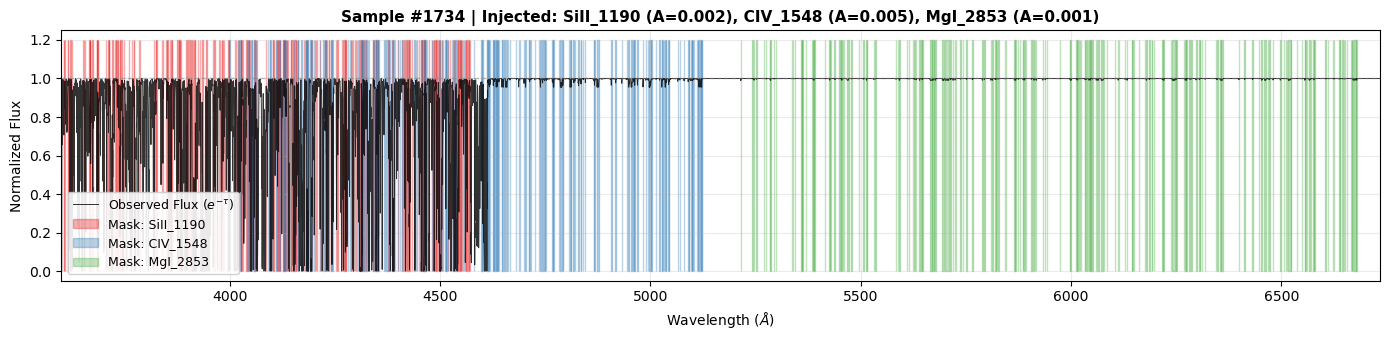

In [22]:
# plot example training data
plot_example_training_samples(
    dataset, 
    metal_dict = metal_dict,
    log_wave_grid = log_wave, 
    num_samples = 1,
)

### Setting up the CNN Architecture

In [23]:
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class SpectralUNet1D(nn.Module):
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = ConvBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = ConvBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = ConvBlock1D(128, 256)
        
        # Decoder
        self.dec3 = ConvBlock1D(256 + 128, 128)
        self.dec2 = ConvBlock1D(128 + 64, 64)
        self.dec1 = ConvBlock1D(64 + 32, 32)
        
        # Output Heads (1D convolutions with 1x1 kernel)
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1) # Logits
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1) # Amplitude log10(A)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        
        # Bottleneck
        b = self.bottleneck(self.pool3(e3))
        
        # Decoder with length-matched upsampling
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        # Heads
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [24]:
class CalibratedMultiMetalLoss(nn.Module):
    def __init__(
        self, 
        metal_dict: dict, 
        lya_wave: float = 1215.67, 
        base_pos_weight: float = 1.0, 
        max_pos_weight: float = 2.5, 
        decay_scale: float = 0.25, 
        reg_weight: float = 1.0
    ):
        """
        Calculates per-species pos_weights dynamically based on log-wavelength distance from LyA.
        
        Parameters:
        -----------
        metal_dict      : Dict mapping species names to rest-frame wavelengths
        lya_wave        : Rest-frame wavelength of LyA (1215.67 A)
        base_pos_weight : Minimum pos_weight for lines far from LyA (e.g. MgI_2853)
        max_pos_weight  : Maximum pos_weight for lines right next to LyA
        decay_scale     : Log-wavelength characteristic distance scale (sigma_d)
        reg_weight      : Multiplier for amplitude regression loss
        """
        super().__init__()
        self.reg_weight = reg_weight
        
        # Calculate per-species pos_weight dynamically
        weights = []
        print("----------------------------------------------------")
        print("--- Automatic Per-Species Classification Weights ---")
        for species, w_metal in metal_dict.items():
            # Distance in log-wavelength space
            log_dist = abs(np.log(w_metal / lya_wave))
            
            # Exponential decay mapping distance to pos_weight
            weight = base_pos_weight + (max_pos_weight - base_pos_weight) * np.exp(-log_dist / decay_scale)
            weights.append(weight)
            print(f"  {species:12s} | lambda = {w_metal:8.2f} A | dist = {log_dist:.4f} | pos_weight = {weight:.3f}")
        print("----------------------------------------------------\n")

        # Reshape to [1, num_species, 1] for 3D tensor broadcasting: [B, C, N]
        pos_weight_tensor = torch.tensor(weights, dtype=torch.float32).view(1, -1, 1)
        self.register_buffer("pos_weight", pos_weight_tensor)

    def forward(self, pred_logits, pred_amp, target_mask, target_amp):
        """
        pred_logits : [B, num_species, N_pixels]
        pred_amp    : [B, num_species, N_pixels]
        target_mask : [B, num_species, N_pixels]
        target_amp  : [B, num_species, N_pixels]
        """
        # 1. Classification Loss with [1, num_species, 1] broadcasting
        loss_cls = F.binary_cross_entropy_with_logits(
            pred_logits, 
            target_mask, 
            pos_weight=self.pos_weight.to(pred_logits.device)
        )
        
        # 2. Masked Amplitude Regression Loss on Active Pixels Only
        active_mask = target_mask > 0.5
        num_positives = active_mask.sum()

        if num_positives > 0:
            # Mean Smooth L1 loss strictly across GT active pixels
            loss_reg = F.smooth_l1_loss(
                pred_amp[active_mask], 
                target_amp[active_mask], 
                reduction='mean'
            )
        else:
            loss_reg = torch.tensor(0.0, device=pred_logits.device)

        total_loss = loss_cls + self.reg_weight * loss_reg
        return total_loss, loss_cls, loss_reg

In [25]:
# class CalibratedMultiMetalLoss(nn.Module):
#     def __init__(self, pos_weight: float = 2.5, reg_weight: float = 1.0):
#         super().__init__()
#         self.register_buffer("pos_weight", torch.tensor([pos_weight]))
#         self.reg_weight = reg_weight
#         self.smooth_l1 = nn.SmoothL1Loss(reduction='sum')

#     def forward(self, pred_logits, pred_amp, target_mask, target_amp):
#         # 1. Classification Loss (Functional BCE avoids re-instantiating nn.Module every pass)
#         loss_cls = F.binary_cross_entropy_with_logits(
#             pred_logits, 
#             target_mask, 
#             pos_weight=self.pos_weight.to(pred_logits.device),
#         )
        
#         # 2. Boolean Indexing for Active Metal Pixels
#         active_mask = target_mask > 0.5
#         num_positives = active_mask.sum()

#         if num_positives > 0:
#             # Extract ONLY active pixels for regression loss
#             loss_reg = self.smooth_l1(
#                 pred_amp[active_mask], 
#                 target_amp[active_mask])
#         else:
#             loss_reg = torch.tensor(0.0, device=pred_logits.device)
                
#         total_loss = loss_cls + self.reg_weight * loss_reg
#         return total_loss, loss_cls, loss_reg


In [26]:
class DilatedBlock1D(nn.Module):
    """
    Multi-scale 1D block using dilated convolutions to expand receptive field
    for cross-correlating line profiles across forest clutter.
    """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1, dilation=1)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=2, dilation=2)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.conv3 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=4, dilation=4)
        self.bn3   = nn.BatchNorm1d(out_ch)
        
        self.shortcut = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        res = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return F.relu(x + res)

class SpectralDilatedUNet1D(nn.Module):
    def __init__(self, in_channels: int, num_species: int):
        super().__init__()
        # Encoder
        self.enc1 = DilatedBlock1D(in_channels, 32)
        self.pool1 = nn.MaxPool1d(2)
        self.enc2 = DilatedBlock1D(32, 64)
        self.pool2 = nn.MaxPool1d(2)
        self.enc3 = DilatedBlock1D(64, 128)
        self.pool3 = nn.MaxPool1d(2)
        
        # Bottleneck
        self.bottleneck = DilatedBlock1D(128, 256)
        
        # Decoder
        self.dec3 = DilatedBlock1D(256 + 128, 128)
        self.dec2 = DilatedBlock1D(128 + 64, 64)
        self.dec1 = DilatedBlock1D(64 + 32, 32)
        
        # Output Heads
        self.cls_head = nn.Conv1d(32, num_species, kernel_size=1)
        self.reg_head = nn.Conv1d(32, num_species, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool3(e2))
        
        b = self.bottleneck(self.pool3(e3))
        
        d3 = F.interpolate(b, size=e3.shape[-1], mode='linear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = F.interpolate(d3, size=e2.shape[-1], mode='linear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = F.interpolate(d2, size=e1.shape[-1], mode='linear', align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        mask_logits = self.cls_head(d1)
        amp_pred = self.reg_head(d1)
        
        return mask_logits, amp_pred

In [27]:
epochs = 10

In [28]:
# # 2. Model, Loss, Optimizer
# num_channels = train_dataset[0][0].shape[0]  # e.g., 2 channels (1 raw + 1 shifted)
# num_species = train_dataset[0][1].shape[0]   # e.g., 1 species

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# # model = SpectralUNet1D(in_channels=num_channels, num_species=num_species).to(device)
# model = SpectralDilatedUNet1D(in_channels=num_channels, num_species=num_species).to(device)

# # Positional weight ~ 8.0 to balance 90% continuum vs 10% line pixels
# criterion = CalibratedMultiMetalLoss(pos_weight=2.5, reg_weight=1.0)
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [29]:
# 1. Train/Validation Split (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=16, shuffle=True) # Reduced batch size to 16 for memory
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

# 2. Model, Loss, Optimizer
num_channels = dataset[0][0].shape[0]  # e.g., 2 channels (1 raw + 1 shifted)
num_species = dataset[0][1].shape[0]   # e.g., 1 species

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

# model = SpectralUNet1D(in_channels=num_channels, num_species=num_species).to(device)
model = SpectralDilatedUNet1D(in_channels=num_channels, num_species=num_species).to(device)

# Pass species-specific weights to BCE with logits
criterion = CalibratedMultiMetalLoss(
    metal_dict=metal_dict,
    lya_wave=lya_wave,
    base_pos_weight=1.0,    # Far lines like MgI get pos_weight ~ 1.05
    max_pos_weight=2.5,     # Close lines like SiII get pos_weight ~ 2.13
    decay_scale=0.25,
    reg_weight=1.0
    ).to(device)

# criterion = CalibratedMultiMetalLoss(pos_weight=1.0, reg_weight=1.0).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

----------------------------------------------------
--- Automatic Per-Species Classification Weights ---
  SiII_1190    | lambda =  1190.42 A | dist = 0.0210 | pos_weight = 2.379
  CIV_1548     | lambda =  1548.20 A | dist = 0.2418 | pos_weight = 1.570
  MgI_2853     | lambda =  2852.96 A | dist = 0.8531 | pos_weight = 1.049
----------------------------------------------------



In [30]:
print("model:", next(model.parameters()).device)
print("loss:", criterion.pos_weight.device)

model: cuda:0
loss: cuda:0


In [32]:
# Setup save paths and config metadata
# checkpoint_path = "MgI_SiII_A_0-02__0-05.pt"
checkpoint_path = "wave_shift-3_met_4.pt"

config_metadata = {
    "in_channels": num_channels,
    "num_species": num_species,
    # "metal_dict": {'MgI_2853': 2852.96, 'SiII(1304)': 1304.3702},
    'metal_dict': metal_dict,
    "lya_wave": lya_wave
}

best_val_loss = float("inf")

In [33]:
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

start = datetime.now()
print('Start time: ', start, '\n')

# 3. Training Loop
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    train_loss, train_cls, train_reg = 0.0, 0.0, 0.0
    
    for X_b, mask_b, amp_b in train_loader:
        X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
        
        optimizer.zero_grad()
        pred_logits, pred_amp = model(X_b)
        
        loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
        loss.backward()
        
        # Clip gradients to prevent loss spikes/instability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * X_b.size(0)
        train_cls += l_cls.item() * X_b.size(0)
        train_reg += l_reg.item() * X_b.size(0)

    # Validation phase
    model.eval()
    val_loss, val_cls, val_reg = 0.0, 0.0, 0.0
    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b, mask_b, amp_b = X_b.to(device), mask_b.to(device), amp_b.to(device)
            
            pred_logits, pred_amp = model(X_b)
            loss, l_cls, l_reg = criterion(pred_logits, pred_amp, mask_b, amp_b)
            
            val_loss += loss.item() * X_b.size(0)
            val_cls += l_cls.item() * X_b.size(0)
            val_reg += l_reg.item() * X_b.size(0)

    scheduler.step()
    
    # Normalize losses by number of samples
    train_loss /= len(train_set)
    train_cls  /= len(train_set)
    train_reg  /= len(train_set)
    
    val_loss /= len(val_set)
    val_cls  /= len(val_set)
    val_reg  /= len(val_set)
    
    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} "
        f"(Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
    )
    
    # Checkpoint based on normalized validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_model_checkpoint(
            filepath=checkpoint_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            val_loss=val_loss,
            config=config_metadata
        )
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} (Cls: {val_cls:.4f}, Reg: {val_reg:.4f})"
        )

end = datetime.now()
print('\nEnd time: ', end, '\n')
elapsed = end - start
print(f"Elapsed time: {elapsed.total_seconds()} seconds")

Start time:  2026-09-22 13:51:16.689622 

Epoch 01/10 | Train Loss: 0.1480 | Val Loss: 0.0446 (Cls: 0.0421, Reg: 0.0025)
--> Saved checkpoint to 'wave_shift-3_met_4.pt' (Epoch 1, Val Loss: 0.0446)
Epoch 02/10 | Train Loss: 0.0439 | Val Loss: 0.0394 (Cls: 0.0370, Reg: 0.0025)
--> Saved checkpoint to 'wave_shift-3_met_4.pt' (Epoch 2, Val Loss: 0.0394)
Epoch 03/10 | Train Loss: 0.0394 | Val Loss: 0.0350 (Cls: 0.0343, Reg: 0.0007)
--> Saved checkpoint to 'wave_shift-3_met_4.pt' (Epoch 3, Val Loss: 0.0350)
Epoch 04/10 | Train Loss: 0.0380 | Val Loss: 0.0344 (Cls: 0.0334, Reg: 0.0010)
--> Saved checkpoint to 'wave_shift-3_met_4.pt' (Epoch 4, Val Loss: 0.0344)
Epoch 05/10 | Train Loss: 0.0359 | Val Loss: 0.0328 (Cls: 0.0322, Reg: 0.0007)
--> Saved checkpoint to 'wave_shift-3_met_4.pt' (Epoch 5, Val Loss: 0.0328)
Epoch 05/10 | Train Loss: 0.0359 | Val Loss: 0.0328 (Cls: 0.0322, Reg: 0.0007)
Epoch 06/10 | Train Loss: 0.0347 | Val Loss: 0.0320 (Cls: 0.0316, Reg: 0.0004)
--> Saved checkpoint to '

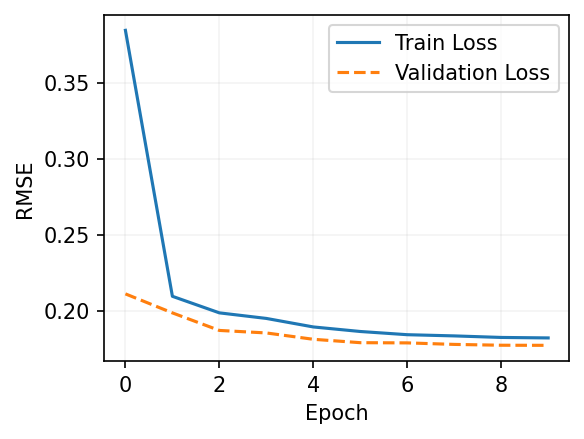

In [34]:
# Plot train / validation loss
plt.figure(figsize=(4,3), dpi=150)
plt.plot(np.sqrt(train_losses), label='Train Loss')
plt.plot(np.sqrt(val_losses), label='Validation Loss', ls='dashed')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
# plt.ylim(0.09, 0.5)
plt.grid(alpha=0.15)
plt.legend()
plt.show()

#### Run some diagnostics

In [35]:
def get_valid_pred_mask(prob_array: np.ndarray, p_thresh: float = 0.5, min_contiguous_pixels: int = 3) -> np.ndarray:
    """
    Returns a boolean mask of shape matching prob_array, where True indicates
    pixels that belong to a contiguous region >= min_contiguous_pixels with prob >= p_thresh.
    """
    binary_mask = prob_array >= p_thresh
    labeled_array, num_features = label(binary_mask)
    
    valid_mask = np.zeros_like(binary_mask, dtype=bool)
    if num_features == 0:
        return valid_mask
        
    for feature_idx in range(1, num_features + 1):
        region = (labeled_array == feature_idx)
        if np.sum(region) >= min_contiguous_pixels:
            valid_mask[region] = True
            
    return valid_mask

def is_valid_spectrum_detection(prob_array: np.ndarray, p_thresh: float = 0.5, min_contiguous_pixels: int = 3) -> bool:
    """Convenience wrapper returning True if any valid contiguous prediction exists."""
    valid_mask = get_valid_pred_mask(prob_array, p_thresh=p_thresh, min_contiguous_pixels=min_contiguous_pixels)
    return np.any(valid_mask)


In [36]:
# def is_valid_spectrum_detection(prob_array, p_thresh=0.5, min_contiguous_pixels=3):
#     """
#     Returns True only if there are at least `min_contiguous_pixels`
#     consecutively exceeding p_thresh in the spectrum.
#     """
#     binary_mask = prob_array >= p_thresh
#     labeled_array, num_features = label(binary_mask)
    
#     if num_features == 0:
#         return False
    
#     for feature_idx in range(1, num_features + 1):
#         if np.sum(labeled_array == feature_idx) >= min_contiguous_pixels:
#             return True
            
#     return False

In [37]:
def darken_color(color, factor=0.65):
        rgb = np.array(to_rgb(color))
        return tuple(rgb * factor)

In [38]:
def evaluate_unet_stats(
    model, 
    val_loader, 
    device, 
    metal_names: list = None, 
    ):

    model.eval()

    all_mask_true = []
    all_amp_true  = []
    all_prob_pred = []
    all_amp_pred  = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b = X_b.to(device)
            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    # Stack shapes -> (N_spectra, M_species, N_pixels)
    mask_true = np.concatenate(all_mask_true, axis=0) 
    # ^ says whether there is a metal line
    amp_true  = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred  = np.concatenate(all_amp_pred, axis=0)

    prob_threshes = []

    ###############################################
    
    fig, ax = plt.subplots(figsize=(8, 5))

    for m_idx, name in enumerate(metal_names):
        # Cycle through colors if there are more metals than colors
        hist_color = CB_color_cycle[m_idx % len(CB_color_cycle)]
        mean_color = darken_color(hist_color)
        
        # GT = ground truth, if metal species is actually present 
        gt_spec = np.any(mask_true[:, m_idx, :] > 0.5, axis=1)
        # ^ does this spectrum contain at least one GT pixel of this metal?
        max_prob = prob_pred[:, m_idx, :].max(axis=1)
        # ^ what is the highest prob. anywhere in this spectrum that 
        # the model assigned to this metal?
    
        print(f"\n\n{name}")
        print("  GT spectra:", gt_spec.sum())
        print("  mean max prob, GT:", max_prob[gt_spec].mean())
        # ^ max. pred. prob. for spectra where species DOES really exist
        print("  mean max prob, non-GT:", max_prob[~gt_spec].mean())
        # ^ max pred. prob. for spectra where species DOES NOT really exist
        # no GT ~ false positive rate at spectrum level 
        print("  median max prob, GT:", np.median(max_prob[gt_spec]))
        print("  median max prob, non-GT:", np.median(max_prob[~gt_spec]))

        print("  Spectra with GT:", np.sum(np.any(mask_true[:, m_idx, :] > 0.5, axis=-1)), "/", mask_true.shape[0])
        print("  Mean amp_true on GT pixels:", amp_true[:, m_idx, :][mask_true[:, m_idx, :] > 0.5].mean() if np.any(mask_true[:,m_idx,:]>0.5) else "N/A", '\n')
    
        print(f"  Max prob per spectrum:", np.percentile(prob_pred[:, m_idx, :].max(axis=-1), [50, 90, 99]),'\n')

        # ^ this checks whether the max pred. prob. is different for spectra 
        # that contain a real (GT) absorber, vs spectra that do not contain any

        prob_threshes.append(max_prob[gt_spec].mean())
    
        for threshold in np.arange(0.2,0.8,0.05):
        # [0.20, 0.25, 0.27, 0.28, 0.29, 0.30]:
            pred = max_prob >= threshold
            tp = np.sum(gt_spec & pred)
            fp = np.sum(~gt_spec & pred)
            fn = np.sum(gt_spec & ~pred)
    
            purity = tp / (tp + fp) if tp + fp else 0
            completeness = tp / (tp + fn) if tp + fn else 0
    
            print(
                f"  p>{threshold:.2f}: "
                f"pred={pred.sum():4d}, "
                f"purity={purity:.3f}, "
                f"completeness={completeness:.3f}"
            )
            
        ax.hist(
            max_prob[gt_spec],
            bins=30,
            alpha=0.5,
            color=hist_color,
            label=f"{name} — GT"
        )
    
        ax.axvline(
            max_prob[gt_spec].mean(),
            linestyle="--",
            color=mean_color,
            linewidth=2,
            label=f"{name} mean"
        )

            # ax.hist(
        #     max_prob[~gt_spec],
        #     bins=30,
        #     alpha=0.5,
        #     label=f"{name} — no GT"
        # )
        # ax.axvline(max_prob[gt_spec].mean(), linestyle="--", label=f"{name} mean", color='k')
    
    # ax.axvline(0.5, linestyle="--", label="threshold")
    ax.set_xlabel("Maximum predicted probability per spectrum")
    ax.set_ylabel("Number of spectra")
    ax.legend()
    plt.show()
    
    return(prob_threshes)



In [39]:
def evaluate_fixed_amplitude_unet(
    model, 
    val_loader, 
    device, 
    metal_names: list = None, 
    prob_thresh: Union[float, Dict[str, float], List[float]] = 0.5,
    min_contiguous_pixels: Union[int, Dict[str, int], List[int]] = 3,
    inputs_in_log_space: bool = True,
    plot: bool = True,
    print_stats: bool = True,
):
    
    model.eval()

    all_mask_true = []
    all_amp_true  = []
    all_prob_pred = []
    all_amp_pred  = []

    with torch.no_grad():
        for X_b, mask_b, amp_b in val_loader:
            X_b = X_b.to(device)
            logits_pred, amp_pred = model(X_b)
            probs_pred = torch.sigmoid(logits_pred)

            all_mask_true.append(mask_b.cpu().numpy())
            all_amp_true.append(amp_b.cpu().numpy())
            all_prob_pred.append(probs_pred.cpu().numpy())
            all_amp_pred.append(amp_pred.cpu().numpy())

    mask_true = np.concatenate(all_mask_true, axis=0)
    amp_true  = np.concatenate(all_amp_true, axis=0)
    prob_pred = np.concatenate(all_prob_pred, axis=0)
    amp_pred  = np.concatenate(all_amp_pred, axis=0)

    if inputs_in_log_space:
        amp_true = 10.0 ** amp_true
        amp_pred = 10.0 ** amp_pred

    num_spectra, num_species, _ = mask_true.shape
    if metal_names is None:
        metal_names = [f"Species_{i+1}" for i in range(num_species)]

    for m_idx, species_name in enumerate(metal_names):
        # Resolve thresholds
        if isinstance(prob_thresh, dict):
            current_p_thresh = prob_thresh.get(species_name, 0.5)
        elif isinstance(prob_thresh, (list, tuple)):
            current_p_thresh = prob_thresh[m_idx]
        else:
            current_p_thresh = float(prob_thresh)

        if isinstance(min_contiguous_pixels, dict):
            current_min_contig = min_contiguous_pixels.get(species_name, 3)
        elif isinstance(min_contiguous_pixels, (list, tuple)):
            current_min_contig = min_contiguous_pixels[m_idx]
        else:
            current_min_contig = int(min_contiguous_pixels)

        # Pixel-level variables
        m_mask_true = mask_true[:, m_idx, :].flatten()
        m_amp_true  = amp_true[:, m_idx, :].flatten()
        m_prob_pred = prob_pred[:, m_idx, :].flatten()
        m_amp_pred  = amp_pred[:, m_idx, :].flatten()

        is_true = m_mask_true > 0.5
        is_pred = m_prob_pred >= current_p_thresh
        is_tp   = is_true & is_pred

        tp_pix = np.sum(is_tp)
        fp_pix = np.sum(~is_true & is_pred)
        fn_pix = np.sum(is_true & ~is_pred)
        tn_pix = np.sum(~is_true & ~is_pred)

        # --- Spectrum-Level Classification with Spatial Intersection ---
        tp_spec, fp_spec, fn_spec, tn_spec = 0, 0, 0, 0
        spec_true_a0 = []
        spec_pred_amps_tp = []
        spec_pred_probs_tp = []

        for s_idx in range(num_spectra):
            gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
            gt_exists = np.any(gt_pixels)

            # Get filtered spatial mask of valid predictions
            valid_pred_mask = get_valid_pred_mask(
                prob_pred[s_idx, m_idx, :],
                p_thresh=current_p_thresh,
                min_contiguous_pixels=current_min_contig
            )
            pred_exists = np.any(valid_pred_mask)

            # Enforce spatial overlap between prediction and ground truth
            spatial_match = np.any(gt_pixels & valid_pred_mask)

            if gt_exists:
                spec_true_a0.append(np.median(amp_true[s_idx, m_idx, gt_pixels]))
                if spatial_match:
                    tp_spec += 1
                    # Extract amplitude on spatially matched TP pixels
                    tp_pixels = gt_pixels & valid_pred_mask
                    spec_pred_amps_tp.append(np.median(amp_pred[s_idx, m_idx, tp_pixels]))
                    spec_pred_probs_tp.append(np.max(prob_pred[s_idx, m_idx, :]))
                else:
                    fn_spec += 1
                    if pred_exists:
                        fp_spec += 1  # Missed GT line but generated spurious detection elsewhere
            else:
                if pred_exists:
                    fp_spec += 1
                else:
                    tn_spec += 1

        spec_has_gt_count = np.sum(np.any(mask_true[:, m_idx, :] > 0.5, axis=-1))
        spec_purity = tp_spec / (tp_spec + fp_spec) if (tp_spec + fp_spec) > 0 else 0.0
        spec_completeness = tp_spec / (tp_spec + fn_spec) if (tp_spec + fn_spec) > 0 else 0.0

        true_a0 = np.median(spec_true_a0) if len(spec_true_a0) > 0 else 0.0
        spec_pred_amps_tp = np.array(spec_pred_amps_tp)
        spec_pred_probs_tp = np.array(spec_pred_probs_tp)

        if len(spec_pred_amps_tp) > 0:
            pred_median = np.median(spec_pred_amps_tp)
            p16, p84 = np.percentile(spec_pred_amps_tp, [16, 84])
            sigma_68 = (p84 - p16) / 2.0
            bias = pred_median - true_a0
            spec_mae = np.mean(np.abs(spec_pred_amps_tp - true_a0))
        else:
            pred_median, p16, p84, sigma_68, bias, spec_mae = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

        # Output Summary
        if print_stats:
            print("\n" + "="*60)
            print(f" FIXED AMPLITUDE METRICS: {species_name} (True A0 = {true_a0:.4f})")
            print("="*60)
            print(f" SPECTRUM-LEVEL CLASSIFICATION (p >= {current_p_thresh:.2f}, Spatial Match & Min Contig = {current_min_contig} px):")
            print(f"   True Positives:  {tp_spec:4d} | False Positives: {fp_spec:4d}")
            print(f"   False Negatives: {fn_spec:4d} | True Negatives:  {tn_spec:4d}")
            print(f"   Purity (Precision):    {spec_purity:.4f}")
            print(f"   Completeness (Recall): {spec_completeness:.4f}")
            print("-" * 60)
            print(" SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):")
            print(f"   Detected Spectra (TPs):    {len(spec_pred_amps_tp)} / {spec_has_gt_count}")
            print(f"   Predicted Amplitude Median: {pred_median:.4f}")
            print(f"   Global Bias (Pred - True):  {bias:+.4f}")
            print(f"   68% Spread (sigma_68):     {sigma_68:.4f}")
            print(f"   Spectrum Amplitude MAE:     {spec_mae:.4f}")
            print("="*60)

        # Plotting Diagnostic Grid
        if plot: 
            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
            base_color = CB_color_cycle[m_idx % len(CB_color_cycle)]
            median_color = darken_color(base_color, factor=0.65)
    
            if len(spec_pred_amps_tp) > 0:
                axes[0].hist(spec_pred_amps_tp, bins=30, density=True, color=base_color, alpha=0.7, edgecolor="black")
                axes[0].axvline(true_a0, color="black", linestyle="--", lw=2, label=f"True $A_0$ ({true_a0:.4f})")
                axes[0].axvline(pred_median, color=median_color, linestyle="-", lw=2, label=f"Pred Median ({pred_median:.4f})")
                axes[0].axvspan(p16, p84, color=base_color, alpha=0.25, label=f"68% CI [{p16:.3f}, {p84:.3f}]")
                axes[0].set_xlabel("Predicted Spectrum Amplitude ($A$)")
                axes[0].set_ylabel("Probability Density")
                axes[0].set_title(f"Spectrum-Level Amplitude Recovery\nBias: {bias:+.4f} | $\sigma_{{68}}$: {sigma_68:.4f}")
                axes[0].grid(True, alpha=0.3)
                axes[0].legend(loc="upper right")
            else:
                axes[0, 0].text(0.5, 0.5, "No Detected Spectra", ha="center", va="center")
    
            # Purity & Completeness Curves with Spatial Overlap Sweep
            prob_sweep = np.linspace(0.01, 0.99, 50)
            purities_spec, completenesses_spec = [], []
    
            for p_th in prob_sweep:
                tp_i, fp_i, fn_i = 0, 0, 0
                for s_idx in range(num_spectra):
                    gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
                    gt_exists = np.any(gt_pixels)
    
                    valid_pred_mask = get_valid_pred_mask(
                        prob_pred[s_idx, m_idx, :],
                        p_thresh=p_th,
                        min_contiguous_pixels=current_min_contig
                    )
                    pred_exists = np.any(valid_pred_mask)
                    spatial_match = np.any(gt_pixels & valid_pred_mask)
    
                    if gt_exists:
                        if spatial_match:
                            tp_i += 1
                        else:
                            fn_i += 1
                            if pred_exists:
                                fp_i += 1
                    else:
                        if pred_exists:
                            fp_i += 1
    
                purities_spec.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
                completenesses_spec.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)
    
            axes[1].plot(prob_sweep, purities_spec, label="Spectrum Purity", color="teal", lw=2)
            axes[1].plot(prob_sweep, completenesses_spec, label="Spectrum Completeness", color="darkorange", lw=2)
            axes[1].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Current Thresh ({current_p_thresh:.2f})")
            axes[1].set_xlabel("Detection Probability Threshold")
            axes[1].set_ylabel("Fraction")
            axes[1].set_title(f"Spectrum-Level Purity & Completeness\n(Spatial Match & Min Contig = {current_min_contig} px)")
            axes[1].grid(True, alpha=0.3)
            axes[1].legend(loc="best")
    
            plt.suptitle(f"Fixed-Amplitude Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
            plt.tight_layout()
            plt.show()

In [40]:
# def evaluate_fixed_amplitude_unet(
#     model, 
#     val_loader, 
#     device, 
#     metal_names: list = None, 
#     prob_thresh: Union[float, Dict[str, float], List[float]] = 0.5,
#     min_contiguous_pixels: Union[int, Dict[str, int], List[int]] = 3,
#     inputs_in_log_space: bool = True,
# ):
#     model.eval()

#     all_mask_true = []
#     all_amp_true  = []
#     all_prob_pred = []
#     all_amp_pred  = []

#     with torch.no_grad():
#         for X_b, mask_b, amp_b in val_loader:
#             X_b = X_b.to(device)
#             logits_pred, amp_pred = model(X_b)
#             probs_pred = torch.sigmoid(logits_pred)

#             all_mask_true.append(mask_b.cpu().numpy())
#             all_amp_true.append(amp_b.cpu().numpy())
#             all_prob_pred.append(probs_pred.cpu().numpy())
#             all_amp_pred.append(amp_pred.cpu().numpy())

#     mask_true = np.concatenate(all_mask_true, axis=0)
#     amp_true  = np.concatenate(all_amp_true, axis=0)
#     prob_pred = np.concatenate(all_prob_pred, axis=0)
#     amp_pred  = np.concatenate(all_amp_pred, axis=0)

#     if inputs_in_log_space:
#         amp_true = 10.0 ** amp_true
#         amp_pred = 10.0 ** amp_pred

#     num_spectra, num_species, _ = mask_true.shape
#     if metal_names is None:
#         metal_names = [f"Species_{i+1}" for i in range(num_species)]

#     for m_idx, species_name in enumerate(metal_names):
#         # Resolve thresholds
#         if isinstance(prob_thresh, dict):
#             current_p_thresh = prob_thresh.get(species_name, 0.5)
#         elif isinstance(prob_thresh, (list, tuple)):
#             current_p_thresh = prob_thresh[m_idx]
#         else:
#             current_p_thresh = float(prob_thresh)

#         if isinstance(min_contiguous_pixels, dict):
#             current_min_contig = min_contiguous_pixels.get(species_name, 3)
#         elif isinstance(min_contiguous_pixels, (list, tuple)):
#             current_min_contig = min_contiguous_pixels[m_idx]
#         else:
#             current_min_contig = int(min_contiguous_pixels)

#         # Pixel-level variables
#         m_mask_true = mask_true[:, m_idx, :].flatten()
#         m_amp_true  = amp_true[:, m_idx, :].flatten()
#         m_prob_pred = prob_pred[:, m_idx, :].flatten()
#         m_amp_pred  = amp_pred[:, m_idx, :].flatten()

#         is_true = m_mask_true > 0.5
#         is_pred = m_prob_pred >= current_p_thresh
#         is_tp   = is_true & is_pred

#         tp_pix = np.sum(is_tp)
#         fp_pix = np.sum(~is_true & is_pred)
#         fn_pix = np.sum(is_true & ~is_pred)
#         tn_pix = np.sum(~is_true & ~is_pred)

#         # --- Spectrum-Level Classification with Spatial Intersection ---
#         tp_spec, fp_spec, fn_spec, tn_spec = 0, 0, 0, 0
#         spec_true_a0 = []
#         spec_pred_amps_tp = []
#         spec_pred_probs_tp = []

#         for s_idx in range(num_spectra):
#             gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
#             gt_exists = np.any(gt_pixels)

#             # Get filtered spatial mask of valid predictions
#             valid_pred_mask = get_valid_pred_mask(
#                 prob_pred[s_idx, m_idx, :],
#                 p_thresh=current_p_thresh,
#                 min_contiguous_pixels=current_min_contig
#             )
#             pred_exists = np.any(valid_pred_mask)

#             # Enforce spatial overlap between prediction and ground truth
#             spatial_match = np.any(gt_pixels & valid_pred_mask)

#             if gt_exists:
#                 spec_true_a0.append(np.median(amp_true[s_idx, m_idx, gt_pixels]))
#                 if spatial_match:
#                     tp_spec += 1
#                     # Extract amplitude on spatially matched TP pixels
#                     tp_pixels = gt_pixels & valid_pred_mask
#                     spec_pred_amps_tp.append(np.median(amp_pred[s_idx, m_idx, tp_pixels]))
#                     spec_pred_probs_tp.append(np.max(prob_pred[s_idx, m_idx, :]))
#                 else:
#                     fn_spec += 1
#                     if pred_exists:
#                         fp_spec += 1  # Missed GT line but generated spurious detection elsewhere
#             else:
#                 if pred_exists:
#                     fp_spec += 1
#                 else:
#                     tn_spec += 1

#         spec_has_gt_count = np.sum(np.any(mask_true[:, m_idx, :] > 0.5, axis=-1))
#         spec_purity = tp_spec / (tp_spec + fp_spec) if (tp_spec + fp_spec) > 0 else 0.0
#         spec_completeness = tp_spec / (tp_spec + fn_spec) if (tp_spec + fn_spec) > 0 else 0.0

#         true_a0 = np.median(spec_true_a0) if len(spec_true_a0) > 0 else 0.0
#         spec_pred_amps_tp = np.array(spec_pred_amps_tp)
#         spec_pred_probs_tp = np.array(spec_pred_probs_tp)

#         if len(spec_pred_amps_tp) > 0:
#             pred_median = np.median(spec_pred_amps_tp)
#             p16, p84 = np.percentile(spec_pred_amps_tp, [16, 84])
#             sigma_68 = (p84 - p16) / 2.0
#             bias = pred_median - true_a0
#             spec_mae = np.mean(np.abs(spec_pred_amps_tp - true_a0))
#         else:
#             pred_median, p16, p84, sigma_68, bias, spec_mae = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

#         # Output Summary
#         print("\n" + "="*60)
#         print(f" FIXED AMPLITUDE METRICS: {species_name} (True A0 = {true_a0:.4f})")
#         print("="*60)
#         print(f" SPECTRUM-LEVEL CLASSIFICATION (p >= {current_p_thresh:.2f}, Spatial Match & Min Contig = {current_min_contig} px):")
#         print(f"   True Positives:  {tp_spec:4d} | False Positives: {fp_spec:4d}")
#         print(f"   False Negatives: {fn_spec:4d} | True Negatives:  {tn_spec:4d}")
#         print(f"   Purity (Precision):    {spec_purity:.4f}")
#         print(f"   Completeness (Recall): {spec_completeness:.4f}")
#         print("-" * 60)
#         print(" SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):")
#         print(f"   Detected Spectra (TPs):    {len(spec_pred_amps_tp)} / {spec_has_gt_count}")
#         print(f"   Predicted Amplitude Median: {pred_median:.4f}")
#         print(f"   Global Bias (Pred - True):  {bias:+.4f}")
#         print(f"   68% Spread (sigma_68):     {sigma_68:.4f}")
#         print(f"   Spectrum Amplitude MAE:     {spec_mae:.4f}")
#         print("="*60)

#         # Plotting Diagnostic Grid
#         fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#         base_color = CB_color_cycle[m_idx % len(CB_color_cycle)]
#         median_color = darken_color(base_color, factor=0.65)

#         if len(spec_pred_amps_tp) > 0:
#             axes[0].hist(spec_pred_amps_tp, bins=30, density=True, color=base_color, alpha=0.7, edgecolor="black")
#             axes[0].axvline(true_a0, color="black", linestyle="--", lw=2, label=f"True $A_0$ ({true_a0:.4f})")
#             axes[0].axvline(pred_median, color=median_color, linestyle="-", lw=2, label=f"Pred Median ({pred_median:.4f})")
#             axes[0].axvspan(p16, p84, color=base_color, alpha=0.25, label=f"68% CI [{p16:.3f}, {p84:.3f}]")
#             axes[0].set_xlabel("Predicted Spectrum Amplitude ($A$)")
#             axes[0].set_ylabel("Probability Density")
#             axes[0].set_title(f"Spectrum-Level Amplitude Recovery\nBias: {bias:+.4f} | $\sigma_{{68}}$: {sigma_68:.4f}")
#             axes[0].grid(True, alpha=0.3)
#             axes[0].legend(loc="upper right")
#         else:
#             axes[0, 0].text(0.5, 0.5, "No Detected Spectra", ha="center", va="center")

#         # Purity & Completeness Curves with Spatial Overlap Sweep
#         prob_sweep = np.linspace(0.01, 0.99, 50)
#         purities_spec, completenesses_spec = [], []

#         for p_th in prob_sweep:
#             tp_i, fp_i, fn_i = 0, 0, 0
#             for s_idx in range(num_spectra):
#                 gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
#                 gt_exists = np.any(gt_pixels)

#                 valid_pred_mask = get_valid_pred_mask(
#                     prob_pred[s_idx, m_idx, :],
#                     p_thresh=p_th,
#                     min_contiguous_pixels=current_min_contig
#                 )
#                 pred_exists = np.any(valid_pred_mask)
#                 spatial_match = np.any(gt_pixels & valid_pred_mask)

#                 if gt_exists:
#                     if spatial_match:
#                         tp_i += 1
#                     else:
#                         fn_i += 1
#                         if pred_exists:
#                             fp_i += 1
#                 else:
#                     if pred_exists:
#                         fp_i += 1

#             purities_spec.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
#             completenesses_spec.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

#         axes[1].plot(prob_sweep, purities_spec, label="Spectrum Purity", color="teal", lw=2)
#         axes[1].plot(prob_sweep, completenesses_spec, label="Spectrum Completeness", color="darkorange", lw=2)
#         axes[1].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Current Thresh ({current_p_thresh:.2f})")
#         axes[1].set_xlabel("Detection Probability Threshold")
#         axes[1].set_ylabel("Fraction")
#         axes[1].set_title(f"Spectrum-Level Purity & Completeness\n(Spatial Match & Min Contig = {current_min_contig} px)")
#         axes[1].grid(True, alpha=0.3)
#         axes[1].legend(loc="best")

#         plt.suptitle(f"Fixed-Amplitude Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
#         plt.tight_layout()
#         plt.show()

In [41]:
def plot_sample_predictions(
    model: torch.nn.Module,
    val_loader: torch.utils.data.DataLoader,
    device: torch.device,
    metal_dict: dict,
    num_samples: int = 3,
    prob_threshold: float = 0.5
):
    """
    Plots observed optical depth, ground truth metal masks, raw model logits, 
    and output probabilities for visual alignment inspection.
    """
    model.eval()
    species_names = list(metal_dict.keys())
    num_species = len(species_names)
    
    # Get a single batch from the validation loader
    with torch.no_grad():
        for x_batch, y_mask_batch, y_amp_batch in val_loader:
            x_batch = x_batch.to(device)
            
            # Forward pass (handles single or dual-head U-Net output)
            outputs = model(x_batch)
            if isinstance(outputs, tuple):
                logits_cls, pred_amp = outputs
            else:
                logits_cls = outputs
                pred_amp = None
            
            probs_cls = torch.sigmoid(logits_cls)
            
            # Convert tensors to numpy for plotting
            tau_obs = x_batch[:, 0, :].cpu().numpy()
            y_mask = y_mask_batch.cpu().numpy()
            logits = logits_cls.cpu().numpy()
            probs = probs_cls.cpu().numpy()
            
            break  # Process only the first batch

    pixel_grid = np.arange(tau_obs.shape[1])
    
    for i in range(min(num_samples, tau_obs.shape[0])):
        fig, axes = plt.subplots(
            2 + num_species, 1, 
            figsize=(14, 2.5 * (2 + num_species)), 
            sharex=True
        )
        
        # --- Panel 1: Observed Optical Depth (Tau_obs) ---
        axes[0].plot(pixel_grid, tau_obs[i], color='black', lw=1.2, label=r'Observed $\tau_{\mathrm{obs}}$')
        axes[0].set_ylabel(r'$\tau_{\mathrm{obs}}$')
        axes[0].set_title(f'Sample Sightline #{i+1}', fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc='upper right')

        # --- Panel 2: Raw Model Logits ---
        for s_idx, sp in enumerate(species_names):
            axes[1].plot(pixel_grid, logits[i, s_idx], label=f'{sp} Logit', lw=1.5, alpha=0.75)
        # Mark neutral zero-logit line (equivalent to p = 0.5 without pos_weight adjustment)
        axes[1].axhline(0.0, color='gray', linestyle='--', alpha=0.7, label='Logit = 0')
        axes[1].set_ylabel('Raw Logits')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='upper right')

        # --- Panel 3+: Predicted Probabilities vs Ground Truth per Species ---
        for s_idx, sp in enumerate(species_names):
            ax = axes[2 + s_idx]
            
            # Ground truth line mask shade
            gt_mask = y_mask[i, s_idx]
            ax.fill_between(
                pixel_grid, 0, 1, where=(gt_mask > 0.5), 
                color='green', alpha=0.25, label='GT Absorption Region'
            )
            
            # Model Predicted Probability
            ax.plot(pixel_grid, probs[i, s_idx], color='crimson', lw=0.5, label=f'Pred Prob ({sp})')
            ax.axhline(prob_threshold, color='navy', linestyle=':', label=f'Threshold p={prob_threshold}')
            
            ax.set_ylim(-0.05, 1.05)
            ax.set_ylabel('Probability')
            ax.set_xlabel('Pixel Index')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper right')

        plt.tight_layout()
        plt.show()

In [42]:
# def evaluate_fixed_amplitude_unet(
#     model, 
#     val_loader, 
#     device, 
#     metal_names: list = Noe, 
#     prob_thresh: Union[float, Dict[str, float], List[float]] = 0.5,
#     min_contiguous_pixels: Union[int, Dict[str, int], List[int]] = 3,
#     inputs_in_log_space: bool = True,
# ):
#     model.eval()

#     all_mask_true = []
#     all_amp_true  = []
#     all_prob_pred = []
#     all_amp_pred  = []

#     with torch.no_grad():
#         for X_b, mask_b, amp_b in val_loader:
#             X_b = X_b.to(device)
#             logits_pred, amp_pred = model(X_b)
#             probs_pred = torch.sigmoid(logits_pred)

#             all_mask_true.append(mask_b.cpu().numpy())
#             all_amp_true.append(amp_b.cpu().numpy())
#             all_prob_pred.append(probs_pred.cpu().numpy())
#             all_amp_pred.append(amp_pred.cpu().numpy())

#     mask_true = np.concatenate(all_mask_true, axis=0)
#     amp_true  = np.concatenate(all_amp_true, axis=0)
#     prob_pred = np.concatenate(all_prob_pred, axis=0)
#     amp_pred  = np.concatenate(all_amp_pred, axis=0)

#     if inputs_in_log_space:
#         amp_true = 10.0 ** amp_true
#         amp_pred = 10.0 ** amp_pred

#     num_spectra, num_species, _ = mask_true.shape
#     if metal_names is None:
#         metal_names = [f"Species_{i+1}" for i in range(num_species)]

#     for m_idx, species_name in enumerate(metal_names):
#         # Resolve thresholds
#         if isinstance(prob_thresh, dict):
#             current_p_thresh = prob_thresh.get(species_name, 0.5)
#         elif isinstance(prob_thresh, (list, tuple)):
#             current_p_thresh = prob_thresh[m_idx]
#         else:
#             current_p_thresh = float(prob_thresh)

#         if isinstance(min_contiguous_pixels, dict):
#             current_min_contig = min_contiguous_pixels.get(species_name, 3)
#         elif isinstance(min_contiguous_pixels, (list, tuple)):
#             current_min_contig = min_contiguous_pixels[m_idx]
#         else:
#             current_min_contig = int(min_contiguous_pixels)

#         # Pixel-level variables
#         m_mask_true = mask_true[:, m_idx, :].flatten()
#         m_amp_true  = amp_true[:, m_idx, :].flatten()
#         m_prob_pred = prob_pred[:, m_idx, :].flatten()
#         m_amp_pred  = amp_pred[:, m_idx, :].flatten()

#         is_true = m_mask_true > 0.5
#         is_pred = m_prob_pred >= current_p_thresh
#         is_tp   = is_true & is_pred

#         tp_pix = np.sum(is_tp)
#         fp_pix = np.sum(~is_true & is_pred)
#         fn_pix = np.sum(is_true & ~is_pred)
#         tn_pix = np.sum(~is_true & ~is_pred)

#         # --- Spectrum-Level Classification with Spatial Intersection ---
#         tp_spec, fp_spec, fn_spec, tn_spec = 0, 0, 0, 0
#         spec_true_a0 = []
#         spec_pred_amps_tp = []
#         spec_pred_probs_tp = []

#         for s_idx in range(num_spectra):
#             gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
#             gt_exists = np.any(gt_pixels)

#             # Get filtered spatial mask of valid predictions
#             valid_pred_mask = get_valid_pred_mask(
#                 prob_pred[s_idx, m_idx, :],
#                 p_thresh=current_p_thresh,
#                 min_contiguous_pixels=current_min_contig
#             )
#             pred_exists = np.any(valid_pred_mask)

#             # Enforce spatial overlap between prediction and ground truth
#             spatial_match = np.any(gt_pixels & valid_pred_mask)

#             if gt_exists:
#                 spec_true_a0.append(np.median(amp_true[s_idx, m_idx, gt_pixels]))
#                 if spatial_match:
#                     tp_spec += 1
#                     # Extract amplitude on spatially matched TP pixels
#                     tp_pixels = gt_pixels & valid_pred_mask
#                     spec_pred_amps_tp.append(np.median(amp_pred[s_idx, m_idx, tp_pixels]))
#                     spec_pred_probs_tp.append(np.max(prob_pred[s_idx, m_idx, :]))
#                 else:
#                     fn_spec += 1
#                     if pred_exists:
#                         fp_spec += 1  # Missed GT line but generated spurious detection elsewhere
#             else:
#                 if pred_exists:
#                     fp_spec += 1
#                 else:
#                     tn_spec += 1

#         spec_has_gt_count = np.sum(np.any(mask_true[:, m_idx, :] > 0.5, axis=-1))
#         spec_purity = tp_spec / (tp_spec + fp_spec) if (tp_spec + fp_spec) > 0 else 0.0
#         spec_completeness = tp_spec / (tp_spec + fn_spec) if (tp_spec + fn_spec) > 0 else 0.0

#         true_a0 = np.median(spec_true_a0) if len(spec_true_a0) > 0 else 0.0
#         spec_pred_amps_tp = np.array(spec_pred_amps_tp)
#         spec_pred_probs_tp = np.array(spec_pred_probs_tp)

#         if len(spec_pred_amps_tp) > 0:
#             pred_median = np.median(spec_pred_amps_tp)
#             p16, p84 = np.percentile(spec_pred_amps_tp, [16, 84])
#             sigma_68 = (p84 - p16) / 2.0
#             bias = pred_median - true_a0
#             spec_mae = np.mean(np.abs(spec_pred_amps_tp - true_a0))
#         else:
#             pred_median, p16, p84, sigma_68, bias, spec_mae = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

#         # Output Summary
#         print("\n" + "="*60)
#         print(f" FIXED AMPLITUDE METRICS: {species_name} (True A0 = {true_a0:.4f})")
#         print("="*60)
#         print(f" SPECTRUM-LEVEL CLASSIFICATION (p >= {current_p_thresh:.2f}, Spatial Match & Min Contig = {current_min_contig} px):")
#         print(f"   True Positives:  {tp_spec:4d} | False Positives: {fp_spec:4d}")
#         print(f"   False Negatives: {fn_spec:4d} | True Negatives:  {tn_spec:4d}")
#         print(f"   Purity (Precision):    {spec_purity:.4f}")
#         print(f"   Completeness (Recall): {spec_completeness:.4f}")
#         print("-" * 60)
#         print(" SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):")
#         print(f"   Detected Spectra (TPs):    {len(spec_pred_amps_tp)} / {spec_has_gt_count}")
#         print(f"   Predicted Amplitude Median: {pred_median:.4f}")
#         print(f"   Global Bias (Pred - True):  {bias:+.4f}")
#         print(f"   68% Spread (sigma_68):     {sigma_68:.4f}")
#         print(f"   Spectrum Amplitude MAE:     {spec_mae:.4f}")
#         print("="*60)

#         # Plotting Diagnostic Grid
#         fig, axes = plt.subplots(2, 2, figsize=(13, 11))

#         if np.sum(is_tp) > 0:
#             pix_residuals = m_amp_pred[is_tp] - m_amp_true[is_tp]
#             axes[0, 0].hist(pix_residuals, bins=50, density=True, color="steelblue", alpha=0.7, edgecolor="black")
#             axes[0, 0].axvline(0, color="red", linestyle="--", lw=2, label="Zero Bias")
#             axes[0, 0].axvline(np.median(pix_residuals), color="darkblue", linestyle="-", lw=2, label=f"Median ({np.median(pix_residuals):+.4f})")
#             axes[0, 0].set_xlabel(r"Pixel Residual ($A_{\mathrm{pred}} - A_0$)")
#             axes[0, 0].set_ylabel("Probability Density")
#             axes[0, 0].set_title(f"Pixel-Level Residuals (True Positives)\nMAE: {np.mean(np.abs(pix_residuals)):.4f}")
#             axes[0, 0].grid(True, alpha=0.3)
#             axes[0, 0].legend(loc="upper right")
#         else:
#             axes[0, 0].text(0.5, 0.5, "No True Positives", ha="center", va="center")

#         if len(spec_pred_amps_tp) > 0:
#             axes[0, 1].hist(spec_pred_amps_tp, bins=30, density=True, color="mediumpurple", alpha=0.7, edgecolor="black")
#             axes[0, 1].axvline(true_a0, color="red", linestyle="--", lw=2, label=f"True $A_0$ ({true_a0:.4f})")
#             axes[0, 1].axvline(pred_median, color="indigo", linestyle="-", lw=2, label=f"Pred Median ({pred_median:.4f})")
#             axes[0, 1].axvspan(p16, p84, color="mediumpurple", alpha=0.25, label=f"68% CI [{p16:.3f}, {p84:.3f}]")
#             axes[0, 1].set_xlabel("Predicted Spectrum Amplitude ($A$)")
#             axes[0, 1].set_ylabel("Probability Density")
#             axes[0, 1].set_title(f"Spectrum-Level Amplitude Recovery\nBias: {bias:+.4f} | $\sigma_{{68}}$: {sigma_68:.4f}")
#             axes[0, 1].grid(True, alpha=0.3)
#             axes[0, 1].legend(loc="upper right")
#         else:
#             axes[0, 1].text(0.5, 0.5, "No Detected Spectra", ha="center", va="center")

#         # Purity & Completeness Curves with Spatial Overlap Sweep
#         prob_sweep = np.linspace(0.01, 0.99, 50)
#         purities_spec, completenesses_spec = [], []

#         for p_th in prob_sweep:
#             tp_i, fp_i, fn_i = 0, 0, 0
#             for s_idx in range(num_spectra):
#                 gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
#                 gt_exists = np.any(gt_pixels)

#                 valid_pred_mask = get_valid_pred_mask(
#                     prob_pred[s_idx, m_idx, :],
#                     p_thresh=p_th,
#                     min_contiguous_pixels=current_min_contig
#                 )
#                 pred_exists = np.any(valid_pred_mask)
#                 spatial_match = np.any(gt_pixels & valid_pred_mask)

#                 if gt_exists:
#                     if spatial_match:
#                         tp_i += 1
#                     else:
#                         fn_i += 1
#                         if pred_exists:
#                             fp_i += 1
#                 else:
#                     if pred_exists:
#                         fp_i += 1

#             purities_spec.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
#             completenesses_spec.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

#         axes[1, 0].plot(prob_sweep, purities_spec, label="Spectrum Purity", color="teal", lw=2)
#         axes[1, 0].plot(prob_sweep, completenesses_spec, label="Spectrum Completeness", color="darkorange", lw=2)
#         axes[1, 0].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Current Thresh ({current_p_thresh:.2f})")
#         axes[1, 0].set_xlabel("Detection Probability Threshold")
#         axes[1, 0].set_ylabel("Fraction")
#         axes[1, 0].set_title(f"Spectrum-Level Purity & Completeness\n(Spatial Match & Min Contig = {current_min_contig} px)")
#         axes[1, 0].grid(True, alpha=0.3)
#         axes[1, 0].legend(loc="best")

#         # Pixel Sweep
#         purities, completenesses = [], []
#         for p_th in prob_sweep:
#             pred_pos = m_prob_pred >= p_th
#             tp_i = np.sum(is_true & pred_pos)
#             fp_i = np.sum(~is_true & pred_pos)
#             fn_i = np.sum(is_true & ~pred_pos)

#             purities.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
#             completenesses.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

#         axes[1, 1].plot(prob_sweep, purities, label="Pixel Purity", color="teal", lw=2)
#         axes[1, 1].plot(prob_sweep, completenesses, label="Pixel Completeness", color="darkorange", lw=2)
#         axes[1, 1].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Thresh ({current_p_thresh:.2f})")
#         axes[1, 1].set_xlabel("Detection Probability Threshold")
#         axes[1, 1].set_ylabel("Fraction")
#         axes[1, 1].set_title("Pixel-Level Purity & Completeness")
#         axes[1, 1].grid(True, alpha=0.3)
#         axes[1, 1].legend(loc="best")

#         plt.suptitle(f"Fixed-Amplitude Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
#         plt.tight_layout()
#         plt.show()

In [43]:
# def evaluate_fixed_amplitude_unet(
#     model, 
#     val_loader, 
#     device, 
#     metal_names: list = None, 
#     prob_thresh: Union[float, Dict[str, float], List[float]] = 0.5,
#     min_contiguous_pixels: Union[int, Dict[str, int], List[int]] = 3,
#     inputs_in_log_space: bool = True,
# ):
#     """
#     Evaluates a 1D U-Net on a dataset with fixed single-amplitude metal lines per species.
#     Reports all metrics and generates plots in linear amplitude units A using spatial filtering.
    
#     `prob_thresh` and `min_contiguous_pixels` can be passed as:
#       - A single scalar (applied to all species)
#       - A dict mapping species names to values, e.g., {'SiII_1260': 0.85, 'MgI_2853': 0.50}
#       - A list matching the order of `metal_names`
#     """
#     model.eval()

#     all_mask_true = []
#     all_amp_true  = []
#     all_prob_pred = []
#     all_amp_pred  = []

#     with torch.no_grad():
#         for X_b, mask_b, amp_b in val_loader:
#             X_b = X_b.to(device)
#             logits_pred, amp_pred = model(X_b)
#             probs_pred = torch.sigmoid(logits_pred)

#             all_mask_true.append(mask_b.cpu().numpy())
#             all_amp_true.append(amp_b.cpu().numpy())
#             all_prob_pred.append(probs_pred.cpu().numpy())
#             all_amp_pred.append(amp_pred.cpu().numpy())

#     # Stack shapes -> (N_spectra, M_species, N_pixels)
#     mask_true = np.concatenate(all_mask_true, axis=0)
#     amp_true  = np.concatenate(all_amp_true, axis=0)
#     prob_pred = np.concatenate(all_prob_pred, axis=0)
#     amp_pred  = np.concatenate(all_amp_pred, axis=0)

#     ###############################################

#     # Convert from log10 space to linear amplitude A if needed
#     if inputs_in_log_space:
#         amp_true = 10.0 ** amp_true
#         amp_pred = 10.0 ** amp_pred

#     num_spectra, num_species, _ = mask_true.shape
#     if metal_names is None:
#         metal_names = [f"Species_{i+1}" for i in range(num_species)]

#     for m_idx, species_name in enumerate(metal_names):
#         # --- Resolve per-species probability threshold ---
#         if isinstance(prob_thresh, dict):
#             current_p_thresh = prob_thresh.get(species_name, 0.5)
#         elif isinstance(prob_thresh, (list, tuple)):
#             current_p_thresh = prob_thresh[m_idx]
#         else:
#             current_p_thresh = float(prob_thresh)

#         # --- Resolve per-species min_contiguous_pixels ---
#         if isinstance(min_contiguous_pixels, dict):
#             current_min_contig = min_contiguous_pixels.get(species_name, 3)
#         elif isinstance(min_contiguous_pixels, (list, tuple)):
#             current_min_contig = min_contiguous_pixels[m_idx]
#         else:
#             current_min_contig = int(min_contiguous_pixels)

#         # Flattened arrays for pixel calculations
#         m_mask_true = mask_true[:, m_idx, :].flatten()
#         m_amp_true  = amp_true[:, m_idx, :].flatten()
#         m_prob_pred = prob_pred[:, m_idx, :].flatten()
#         m_amp_pred  = amp_pred[:, m_idx, :].flatten()

#         is_true = m_mask_true > 0.5
#         is_pred = m_prob_pred >= current_p_thresh
#         is_tp   = is_true & is_pred

#         # --- 1. Pixel-Level Classification Metrics ---
#         tp = np.sum(is_tp)
#         fp = np.sum(~is_true & is_pred)
#         fn = np.sum(is_true & ~is_pred)
#         tn = np.sum(~is_true & ~is_pred)
        
#         purity = tp / (tp + fp) if (tp + fp) > 0 else 0.0
#         completeness = tp / (tp + fn) if (tp + fn) > 0 else 0.0

#         # --- 1. Spectrum-Level Classification with Contiguous Thresholding ---
#         spec_has_gt   = np.any(mask_true[:, m_idx, :] > 0.5, axis=-1)  # Shape: (N_spectra,)
#         spec_max_prob = np.max(prob_pred[:, m_idx, :], axis=-1)       # Shape: (N_spectra,)
        
#         # Apply spatial contiguity detection rule across all spectra
#         spec_is_pred = np.array([
#             is_valid_spectrum_detection(
#                 prob_pred[s_idx, m_idx, :], 
#                 p_thresh=current_p_thresh, 
#                 min_contiguous_pixels=current_min_contig
#             )
#             for s_idx in range(num_spectra)
#         ])

#         tp_spec = np.sum(spec_has_gt & spec_is_pred)
#         fp_spec = np.sum(~spec_has_gt & spec_is_pred)
#         fn_spec = np.sum(spec_has_gt & ~spec_is_pred)
#         tn_spec = np.sum(~spec_has_gt & ~spec_is_pred)

#         spec_purity = tp_spec / (tp_spec + fp_spec) if (tp_spec + fp_spec) > 0 else 0.0
#         spec_completeness = tp_spec / (tp_spec + fn_spec) if (tp_spec + fn_spec) > 0 else 0.0

#         # Extract 1 amplitude per detected true positive spectrum
#         spec_true_a0 = []
#         spec_pred_amps_tp = []
#         spec_pred_probs_tp = []

#         for s_idx in range(num_spectra):
#             gt_pixels = mask_true[s_idx, m_idx, :] > 0.5
#             tp_pixels = gt_pixels & (prob_pred[s_idx, m_idx, :] >= current_p_thresh)

#             if np.any(gt_pixels):
#                 spec_true_a0.append(np.median(amp_true[s_idx, m_idx, gt_pixels]))

#                 if spec_is_pred[s_idx] and np.any(tp_pixels):
#                     spec_pred_amps_tp.append(np.median(amp_pred[s_idx, m_idx, tp_pixels]))
#                     spec_pred_probs_tp.append(spec_max_prob[s_idx])

#         true_a0 = np.median(spec_true_a0) if len(spec_true_a0) > 0 else 0.0
#         spec_pred_amps_tp = np.array(spec_pred_amps_tp)
#         spec_pred_probs_tp = np.array(spec_pred_probs_tp)

#         # Statistics on spectrum-level predictions
#         if len(spec_pred_amps_tp) > 0:
#             pred_median = np.median(spec_pred_amps_tp)
#             p16, p84 = np.percentile(spec_pred_amps_tp, [16, 84])
#             sigma_68 = (p84 - p16) / 2.0
#             bias = pred_median - true_a0
#             spec_mae = np.mean(np.abs(spec_pred_amps_tp - true_a0))
#         else:
#             pred_median, p16, p84, sigma_68, bias, spec_mae = 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

#         # --- 2. Print Summary Metrics ---
#         print("\n" + "="*60)
#         print(f" FIXED AMPLITUDE METRICS: {species_name} (True A0 = {true_a0:.4f})")
#         print("="*60)
#         print(f" SPECTRUM-LEVEL CLASSIFICATION (p >= {current_p_thresh:.2f}, Min Contiguous = {current_min_contig} px):")
#         print(f"   True Positives:  {tp_spec:4d} | False Positives: {fp_spec:4d}")
#         print(f"   False Negatives: {fn_spec:4d} | True Negatives:  {tn_spec:4d}")
#         print(f"   Purity (Precision):    {spec_purity:.4f}")
#         print(f"   Completeness (Recall): {spec_completeness:.4f}")
#         print("-" * 60)
#         # print(" PIXEL-LEVEL CLASSIFICATION:")
#         # print(f"  True Positives:  {tp:8d} | False Positives: {fp:8d}")
#         # print(f"  False Negatives: {fn:8d} | True Negatives:  {tn:8d}")
#         # print(f"  Purity (Precision):    {purity:.4f}")
#         # print(f"  Completeness (Recall): {completeness:.4f}")
#         # print("-" * 60)
#         print(" SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):")
#         print(f"   Detected Spectra (TPs):    {len(spec_pred_amps_tp)} / {np.sum(spec_has_gt)}")
#         print(f"   Predicted Amplitude Median: {pred_median:.4f}")
#         print(f"   Global Bias (Pred - True):  {bias:+.4f}")
#         print(f"   68% Spread (sigma_68):     {sigma_68:.4f}")
#         print(f"   Spectrum Amplitude MAE:     {spec_mae:.4f}")
#         print("="*60)

#         # --- 3. Diagnostics Plotting (2x2 Panel per metal) ---
#         fig, axes = plt.subplots(2, 2, figsize=(13, 11))

#         # Panel 1: Pixel-Level Linear Residual Distribution
#         if np.sum(is_tp) > 0:
#             pix_residuals = m_amp_pred[is_tp] - m_amp_true[is_tp]
#             axes[0, 0].hist(pix_residuals, bins=50, density=True, color="steelblue", alpha=0.7, edgecolor="black")
#             axes[0, 0].axvline(0, color="red", linestyle="--", lw=2, label="Zero Bias")
#             axes[0, 0].axvline(np.median(pix_residuals), color="darkblue", linestyle="-", lw=2, 
#                                label=f"Pixel Median ({np.median(pix_residuals):+.4f})")
#             axes[0, 0].set_xlabel(r"Pixel Residual ($A_{\mathrm{pred}} - A_0$)")
#             axes[0, 0].set_ylabel("Probability Density")
#             axes[0, 0].set_title(f"Pixel-Level Residuals (True Positives)\nMAE: {np.mean(np.abs(pix_residuals)):.4f}")
#             axes[0, 0].grid(True, alpha=0.3)
#             # axes[0, 0].set_xlim(-0.1, 0.1)
#             axes[0, 0].set_xlim(pix_residuals.min(), pix_residuals.max())
#             axes[0, 0].legend(loc="upper right")
#         else:
#             axes[0, 0].text(0.5, 0.5, "No True Positives", ha="center", va="center")

#         # Panel 2: Spectrum-Level Linear Amplitude Distribution
#         if len(spec_pred_amps_tp) > 0:
#             axes[0, 1].hist(spec_pred_amps_tp, bins=30, density=True, color="mediumpurple", alpha=0.7, edgecolor="black")
#             axes[0, 1].axvline(true_a0, color="red", linestyle="--", lw=2, label=f"True $A_0$ ({true_a0:.4f})")
#             axes[0, 1].axvline(pred_median, color="indigo", linestyle="-", lw=2, label=f"Pred Median ({pred_median:.4f})")
#             axes[0, 1].axvspan(p16, p84, color="mediumpurple", alpha=0.25, label=f"68% CI [{p16:.3f}, {p84:.3f}]")
#             axes[0, 1].set_xlabel("Predicted Spectrum Amplitude ($A$)")
#             axes[0, 1].set_ylabel("Probability Density")
#             axes[0, 1].set_title(f"Spectrum-Level Amplitude Recovery\nBias: {bias:+.4f} | $\sigma_{{68}}$: {sigma_68:.4f}")
#             axes[0, 1].grid(True, alpha=0.3)
#             axes[0, 1].legend(loc="upper right")
#         else:
#             axes[0, 1].text(0.5, 0.5, "No Detected Spectra", ha="center", va="center")

#         # Panel 3: Spectrum-Level Purity & Completeness Curves (Contiguous Sweep)
#         prob_sweep = np.linspace(0.01, 0.99, 50)
#         purities_spec, completenesses_spec = [], []
        
#         for p_th in prob_sweep:
#             spec_pred_i = np.array([
#                 is_valid_spectrum_detection(
#                     prob_pred[s_idx, m_idx, :], 
#                     p_thresh=p_th, 
#                     min_contiguous_pixels=current_min_contig
#                 )
#                 for s_idx in range(num_spectra)
#             ])
#             tp_i = np.sum(spec_has_gt & spec_pred_i)
#             fp_i = np.sum(~spec_has_gt & spec_pred_i)
#             fn_i = np.sum(spec_has_gt & ~spec_pred_i)
            
#             purities_spec.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
#             completenesses_spec.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

#         axes[1, 0].plot(prob_sweep, purities_spec, label="Spectrum Purity", color="teal", lw=2)
#         axes[1, 0].plot(prob_sweep, completenesses_spec, label="Spectrum Completeness", color="darkorange", lw=2)
#         axes[1, 0].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Current Thresh ({current_p_thresh:.2f})")
#         axes[1, 0].set_xlabel("Detection Probability Threshold")
#         axes[1, 0].set_ylabel("Fraction")
#         axes[1, 0].set_title(f"Spectrum-Level Purity & Completeness\n(Min Contiguous = {current_min_contig} px)")
#         axes[1, 0].grid(True, alpha=0.3)
#         axes[1, 0].legend(loc="best")

#         # Panel 4: Pixel-Level Purity & Completeness Curves
#         prob_sweep = np.linspace(0.01, 0.99, 50)
#         purities, completenesses = [], []
#         for p_th in prob_sweep:
#             pred_pos = m_prob_pred >= p_th
#             tp_i = np.sum(is_true & pred_pos)
#             fp_i = np.sum(~is_true & pred_pos)
#             fn_i = np.sum(is_true & ~pred_pos)
            
#             purities.append(tp_i / (tp_i + fp_i) if (tp_i + fp_i) > 0 else 1.0)
#             completenesses.append(tp_i / (tp_i + fn_i) if (tp_i + fn_i) > 0 else 1.0)

#         axes[1, 1].plot(prob_sweep, purities, label="Pixel Purity", color="teal", lw=2)
#         axes[1, 1].plot(prob_sweep, completenesses, label="Pixel Completeness", color="darkorange", lw=2)
#         axes[1, 1].axvline(current_p_thresh, color="gray", linestyle=":", label=f"Thresh ({current_p_thresh:.2f})")
#         axes[1, 1].set_xlabel("Detection Probability Threshold")
#         axes[1, 1].set_ylabel("Fraction")
#         axes[1, 1].set_title("Pixel-Level Purity & Completeness")
#         axes[1, 1].grid(True, alpha=0.3)
#         axes[1, 1].legend(loc="best")

#         plt.suptitle(f"Fixed-Amplitude Diagnostic Summary: {species_name}", fontsize=14, y=0.99)
#         plt.tight_layout()
#         plt.show()

### Load an existing model

In [44]:
# Test on the Validation dataset

checkpoint_path = "wave_shift-3_met_4.pt"

model, checkpoint = load_model_checkpoint(
    checkpoint_path,
    device=device,
    model_class=SpectralDilatedUNet1D
)

model.eval()

species_names = list(metal_dict.keys())
species_names

--> Loaded checkpoint 'wave_shift-3_met_4.pt' (Trained for 10 epochs, Val Loss: 0.0314)


['SiII_1190', 'CIV_1548', 'MgI_2853']



SiII_1190
  GT spectra: 658
  mean max prob, GT: 0.9136373
  mean max prob, non-GT: 0.9130772
  median max prob, GT: 0.9119646
  median max prob, non-GT: 0.9089197
  Spectra with GT: 658 / 1000
  Mean amp_true on GT pixels: -2.6989713 

  Max prob per spectrum: [0.91131157 0.93459135 0.94596571] 

  p>0.20: pred=1000, purity=0.658, completeness=1.000
  p>0.25: pred=1000, purity=0.658, completeness=1.000
  p>0.30: pred=1000, purity=0.658, completeness=1.000
  p>0.35: pred=1000, purity=0.658, completeness=1.000
  p>0.40: pred=1000, purity=0.658, completeness=1.000
  p>0.45: pred=1000, purity=0.658, completeness=1.000
  p>0.50: pred=1000, purity=0.658, completeness=1.000
  p>0.55: pred=1000, purity=0.658, completeness=1.000
  p>0.60: pred=1000, purity=0.658, completeness=1.000
  p>0.65: pred=1000, purity=0.658, completeness=1.000
  p>0.70: pred=1000, purity=0.658, completeness=1.000
  p>0.75: pred=1000, purity=0.658, completeness=1.000
  p>0.80: pred=1000, purity=0.658, completeness=1.0

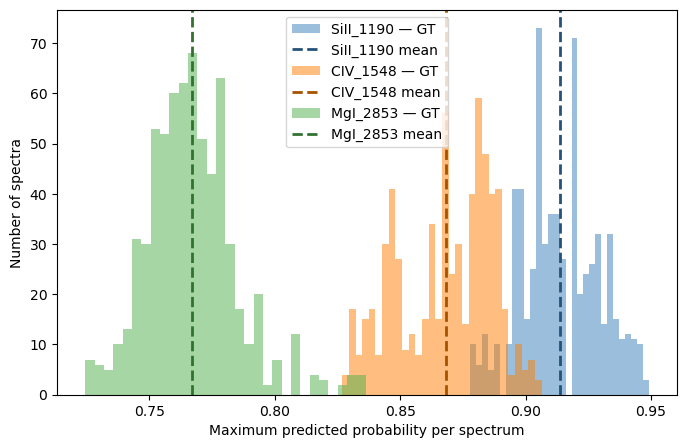

In [45]:
prob_threshes = evaluate_unet_stats(
    model=model,
    val_loader=val_loader,
    device=device,
    metal_names=species_names,
)

In [46]:
prob_threshes

[0.9136373, 0.8681856, 0.7671516]

In [47]:
evaluate_fixed_amplitude_unet(
    model=model,
    val_loader=val_loader,
    device=device,
    metal_names=species_names,
    prob_thresh = [0.9,0.8, 0.7],
    # prob_thresh = 0.1,
    min_contiguous_pixels=3,
    plot=False,
    print_stats=True,
)


 FIXED AMPLITUDE METRICS: SiII_1190 (True A0 = 0.0020)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.90, Spatial Match & Min Contig = 3 px):
   True Positives:   191 | False Positives:   89
   False Negatives:  467 | True Negatives:   253
   Purity (Precision):    0.6821
   Completeness (Recall): 0.2903
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    191 / 658
   Predicted Amplitude Median: 0.0021
   Global Bias (Pred - True):  +0.0001
   68% Spread (sigma_68):     0.0001
   Spectrum Amplitude MAE:     0.0001

 FIXED AMPLITUDE METRICS: CIV_1548 (True A0 = 0.0050)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.80, Spatial Match & Min Contig = 3 px):
   True Positives:   573 | False Positives:  290
   False Negatives:   85 | True Negatives:    52
   Purity (Precision):    0.6640
   Completeness (Recall): 0.8708
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (


 FIXED AMPLITUDE METRICS: MgI_2853 (True A0 = 0.2000)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.80, Spatial Match & Min Contig = 3 px):
   True Positives:  3728 | False Positives:   46
   False Negatives:    0 | True Negatives:  1226
   Purity (Precision):    0.9878
   Completeness (Recall): 1.0000
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    3728 / 3728
   Predicted Amplitude Median: 0.2003
   Global Bias (Pred - True):  +0.0003
   68% Spread (sigma_68):     0.0003
   Spectrum Amplitude MAE:     0.0004


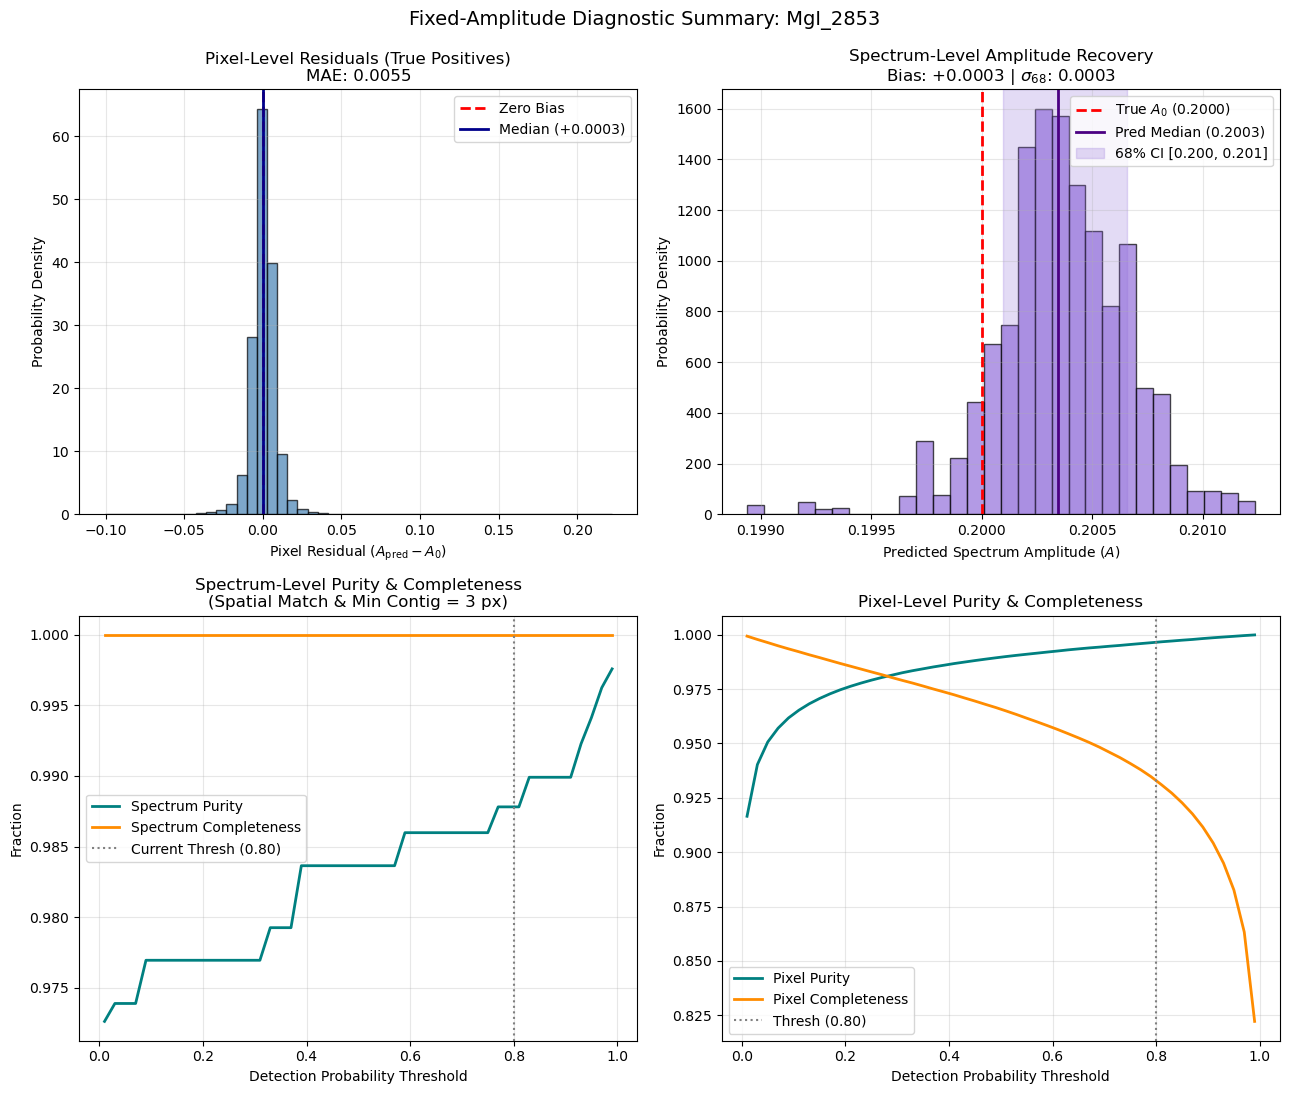


 FIXED AMPLITUDE METRICS: SiII_1304 (True A0 = 0.5000)
 SPECTRUM-LEVEL CLASSIFICATION (p >= 0.80, Spatial Match & Min Contig = 3 px):
   True Positives:  3763 | False Positives:    0
   False Negatives:    0 | True Negatives:  1237
   Purity (Precision):    1.0000
   Completeness (Recall): 1.0000
------------------------------------------------------------
 SPECTRUM-LEVEL AMPLITUDE RECOVERY (Linear Units A):
   Detected Spectra (TPs):    3763 / 3763
   Predicted Amplitude Median: 0.5003
   Global Bias (Pred - True):  +0.0003
   68% Spread (sigma_68):     0.0007
   Spectrum Amplitude MAE:     0.0007


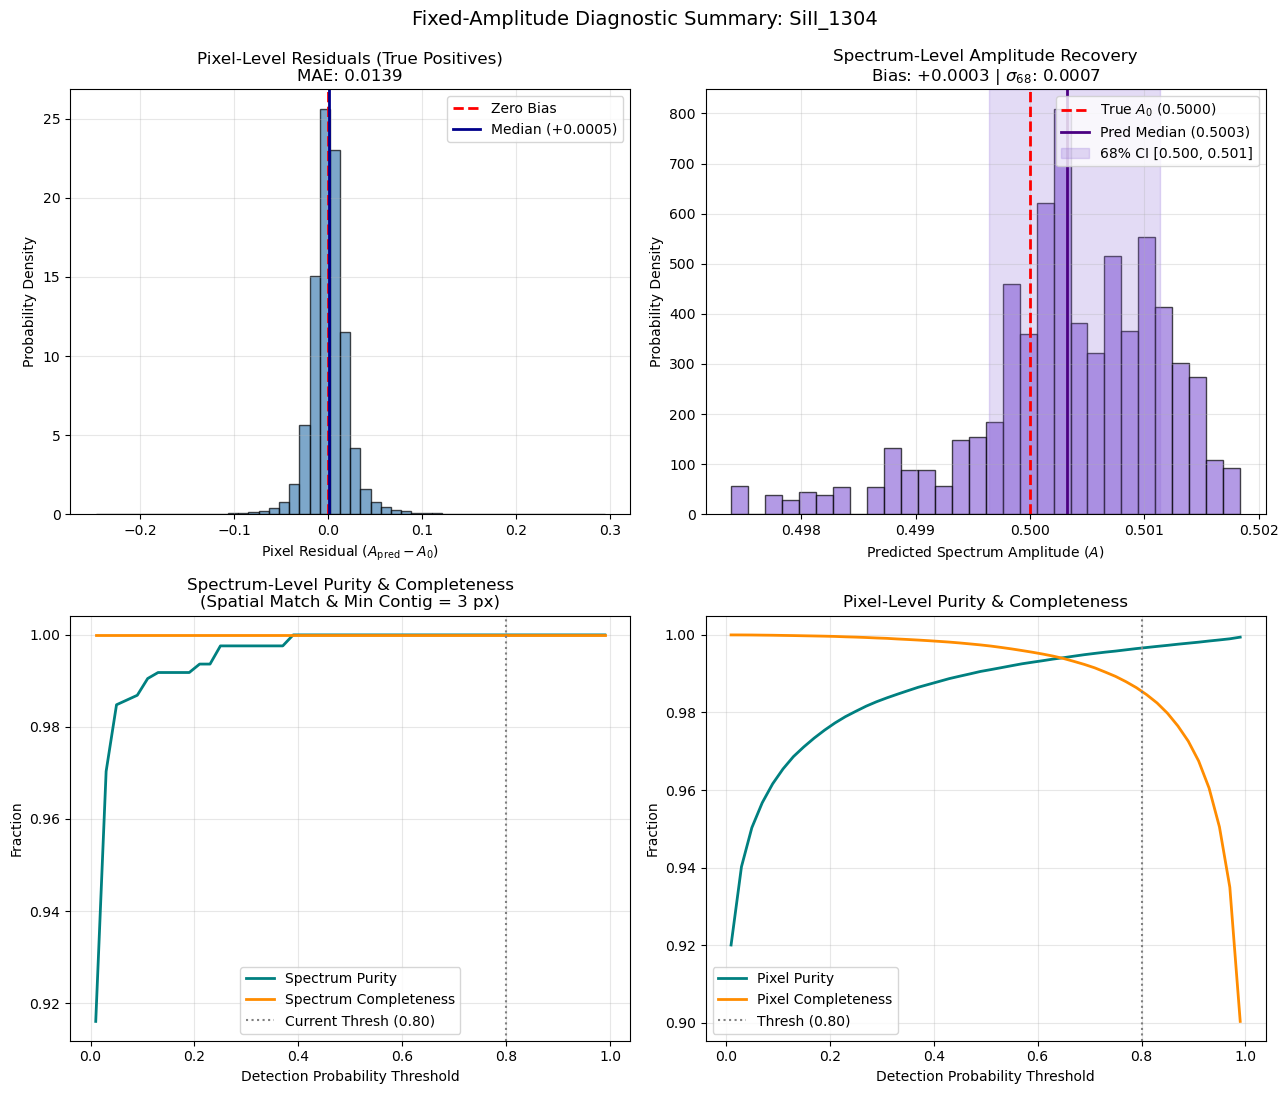

In [34]:
# Test on separate external dataset

test_dataset = generate_multimetal_dataset(
    lya_flux_samples=fluxes_log,
    log_wave_grid=log_wave,
    metal_dict=metal_dict,
    a_min=[0.2, 0.5, 0.1], 
    a_max=[0.2, 0.5, 0.1],
    num_samples=5000,
    max_metals_per_spectrum=3,
    snr=None,
    tau_min_fraction=tau_min_fraction,
    zero_metal_prob=0.0,
)

test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

species_names = list(metal_dict.keys())  # ['MgI_2853', 'SiII(1304)']

# 2. Run diagnostics directly
evaluate_fixed_amplitude_unet(
    model=model,
    val_loader=test_loader,
    device=device,
    metal_names=species_names,
    prob_thresh=[0.8,0.8, 0.8],
    min_contiguous_pixels=3,
)

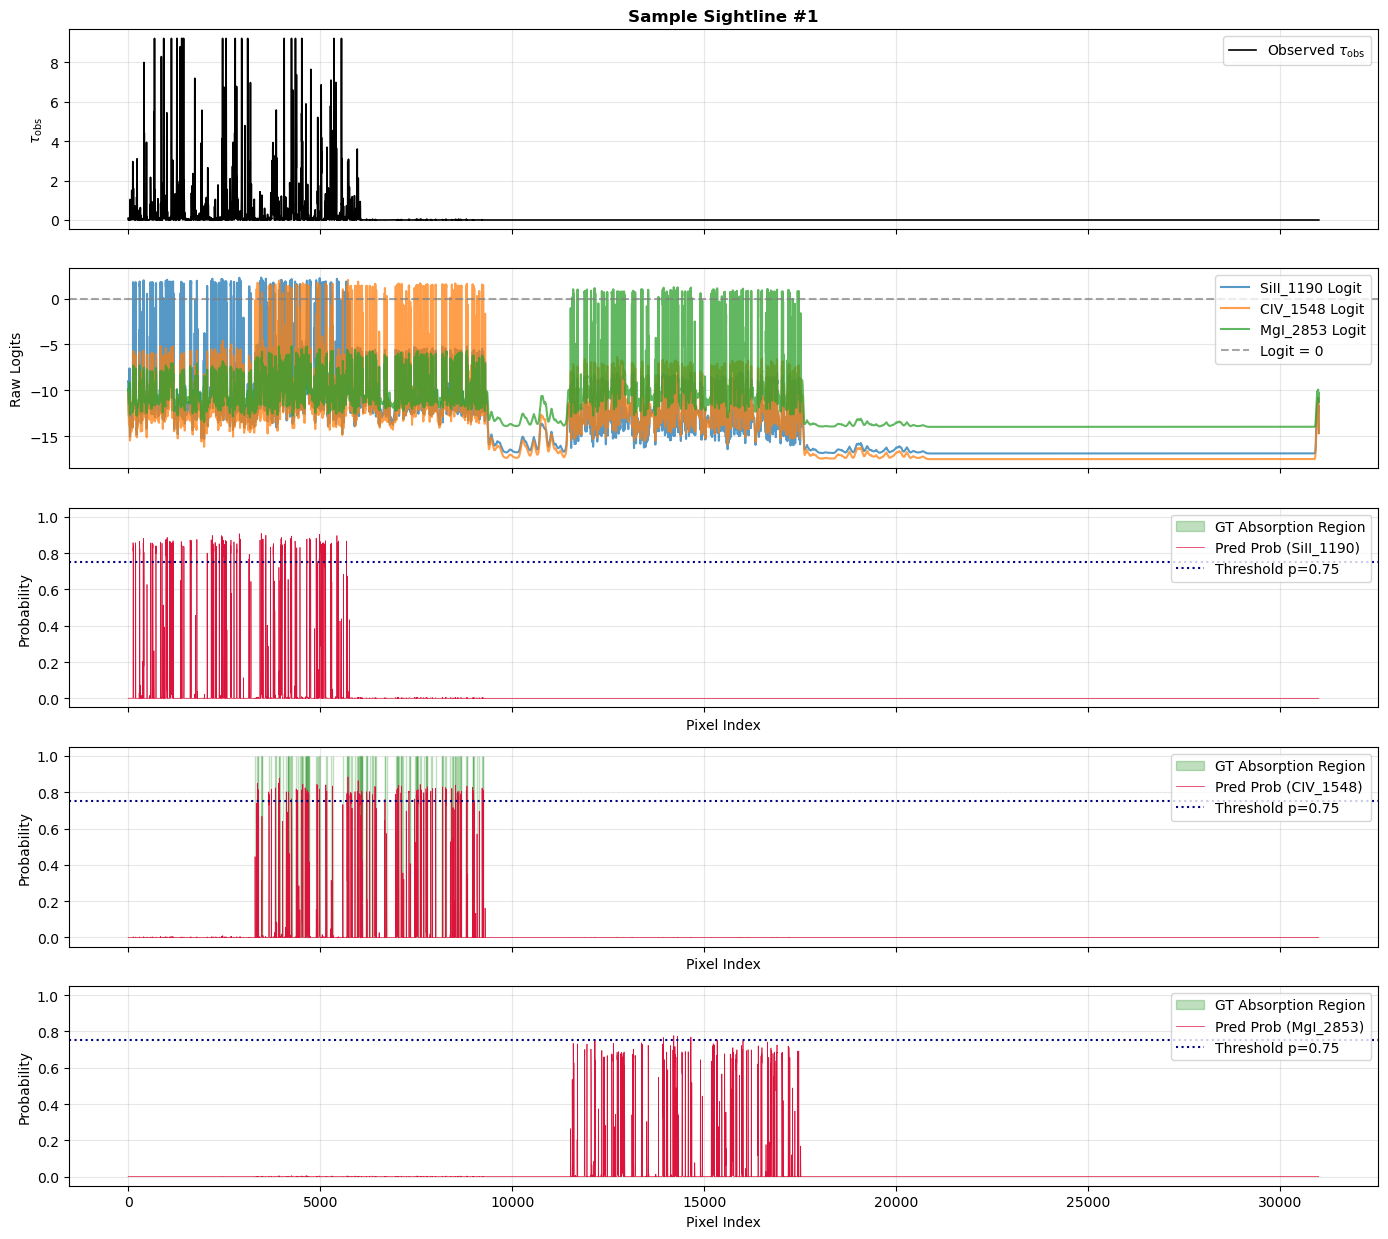

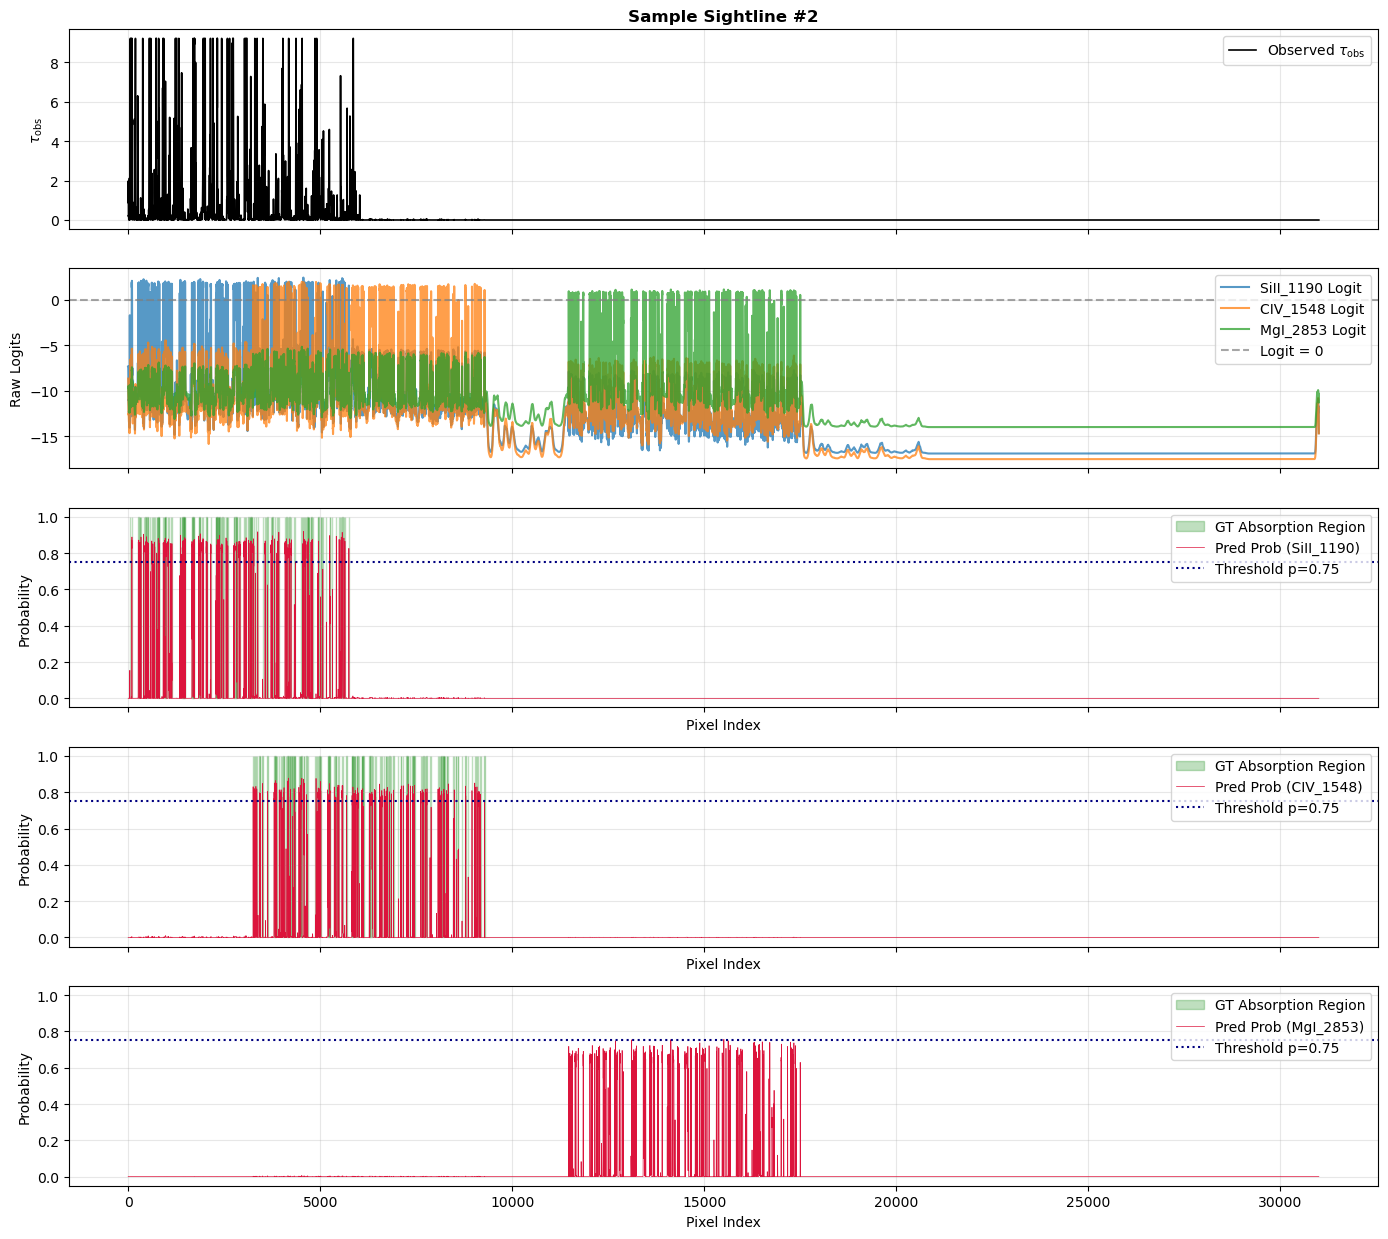

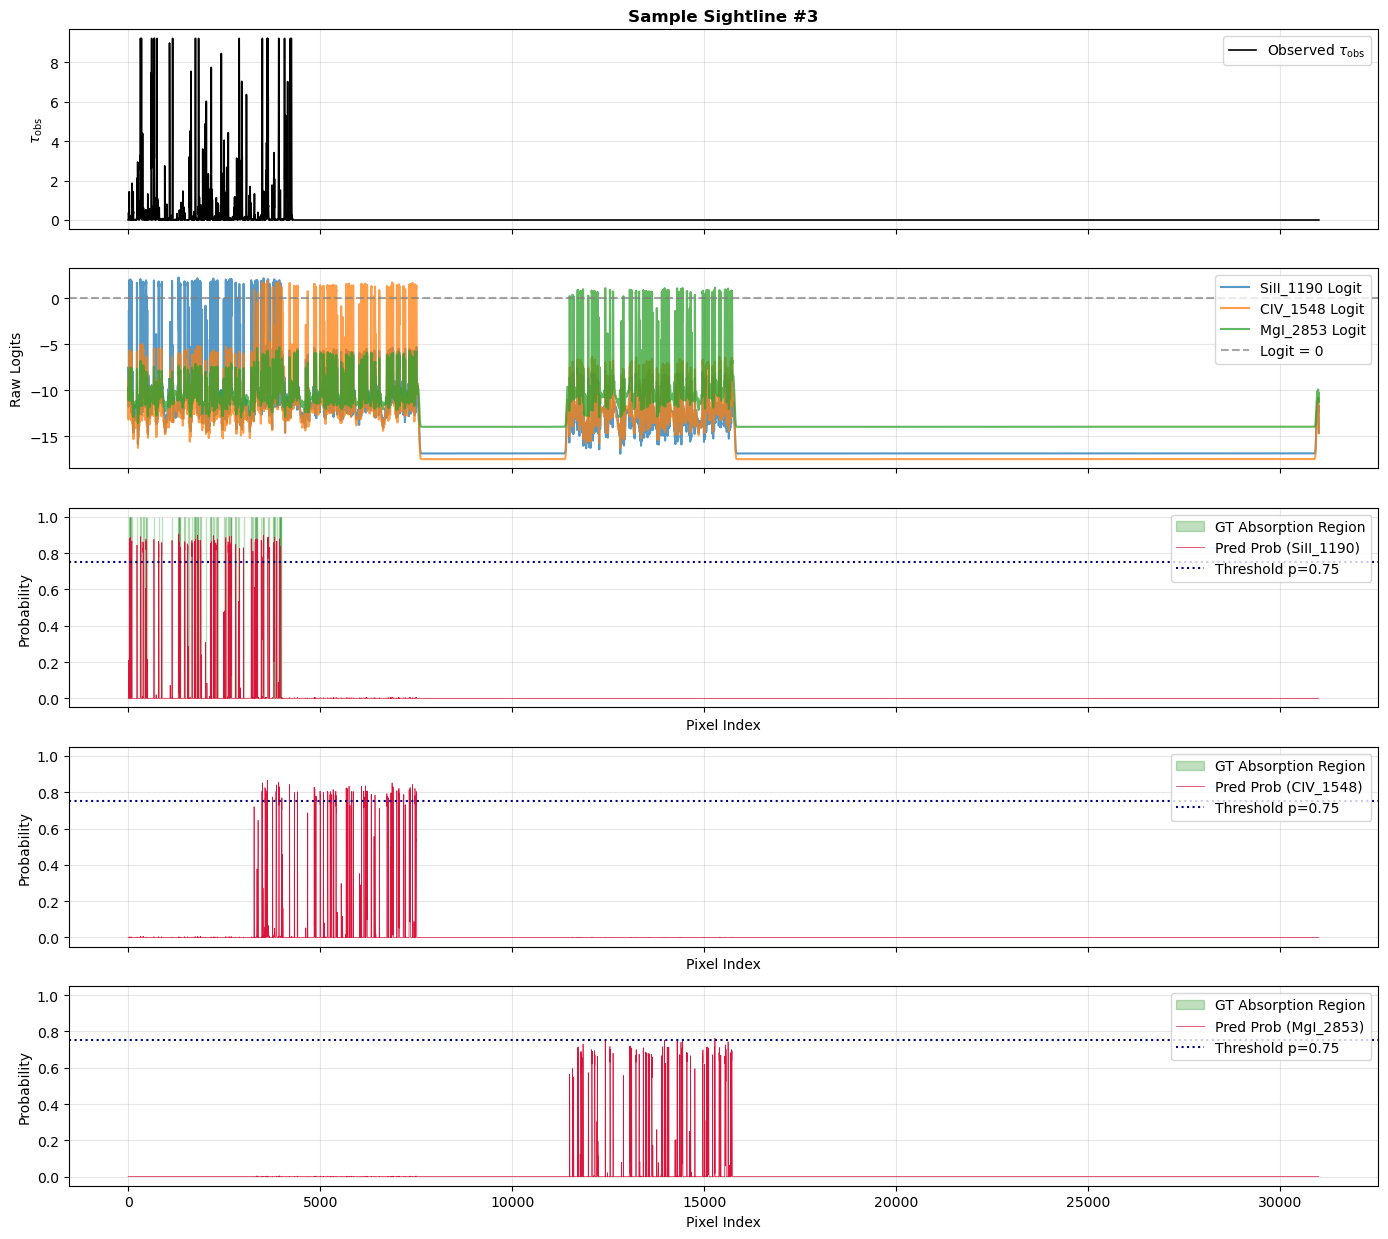

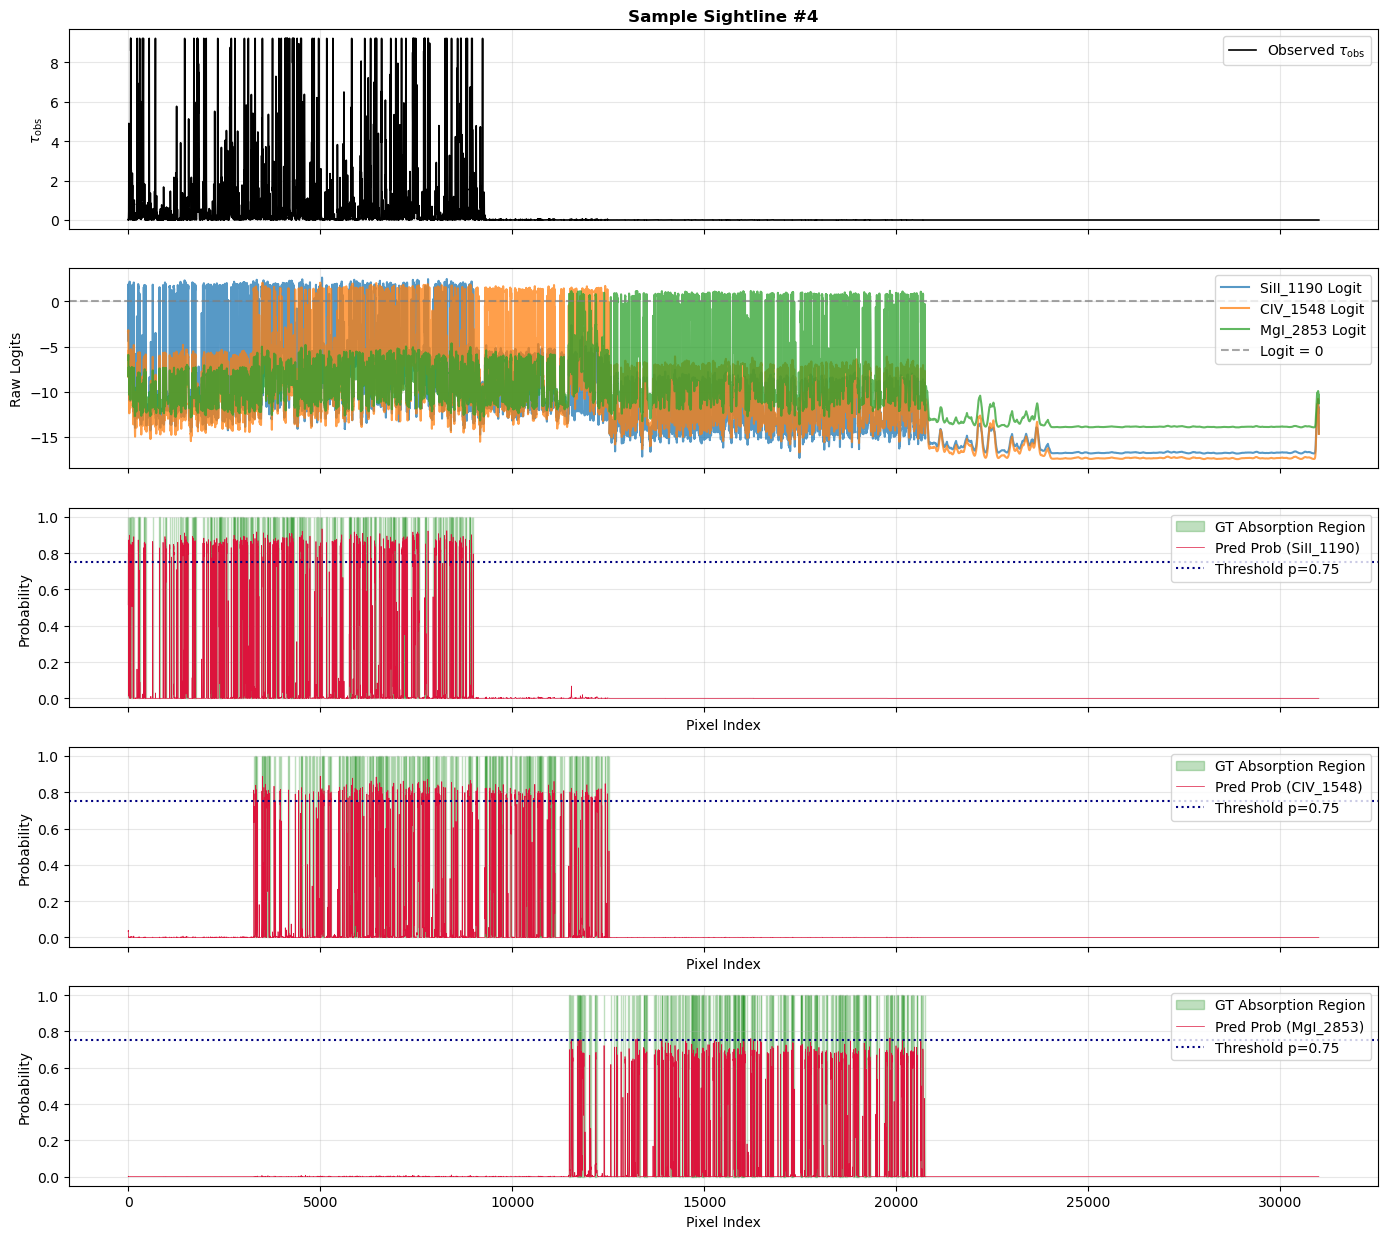

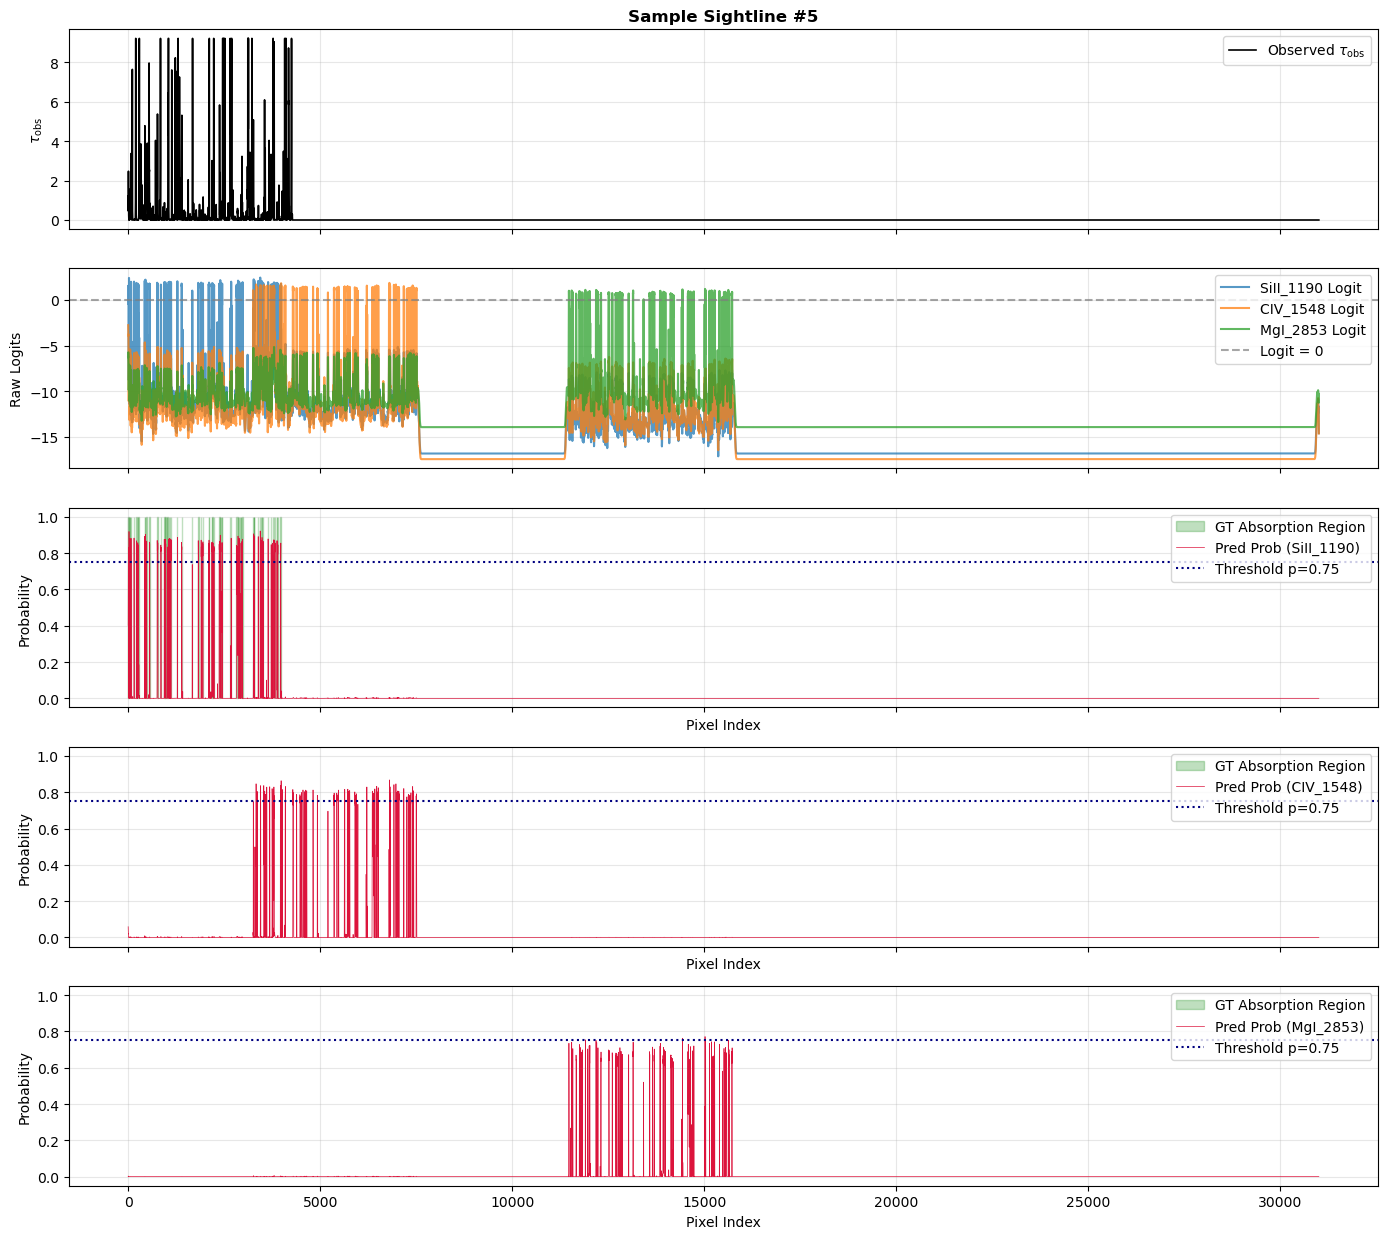

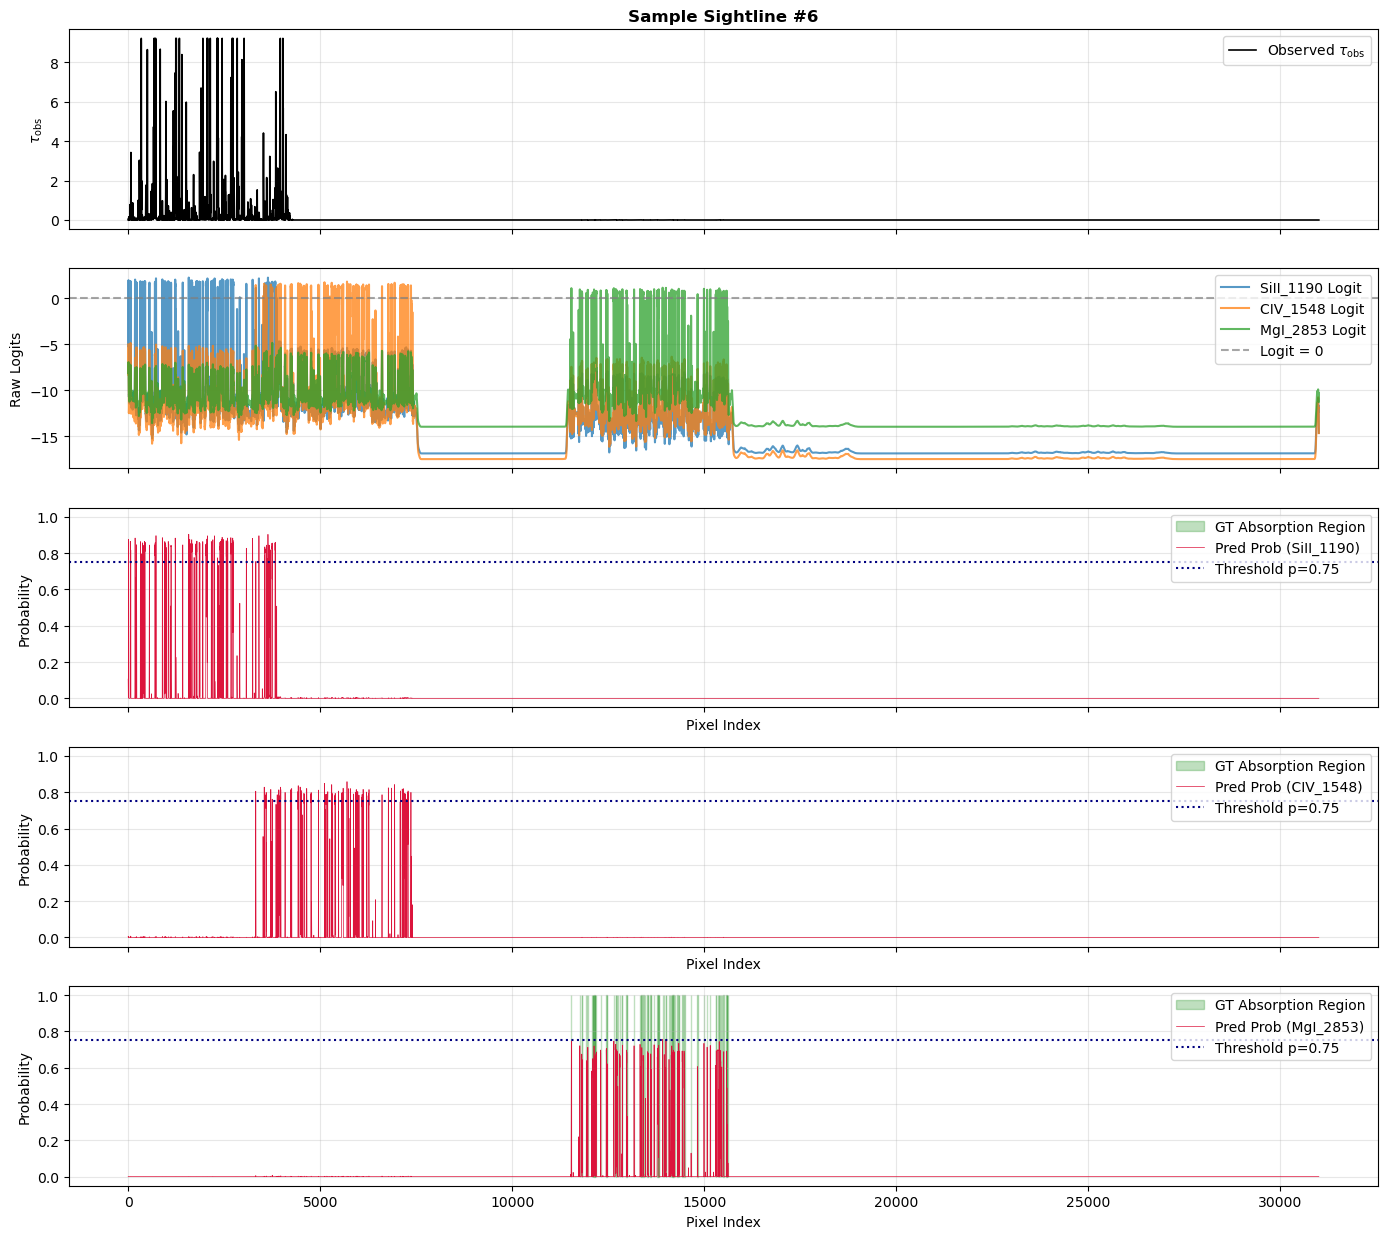

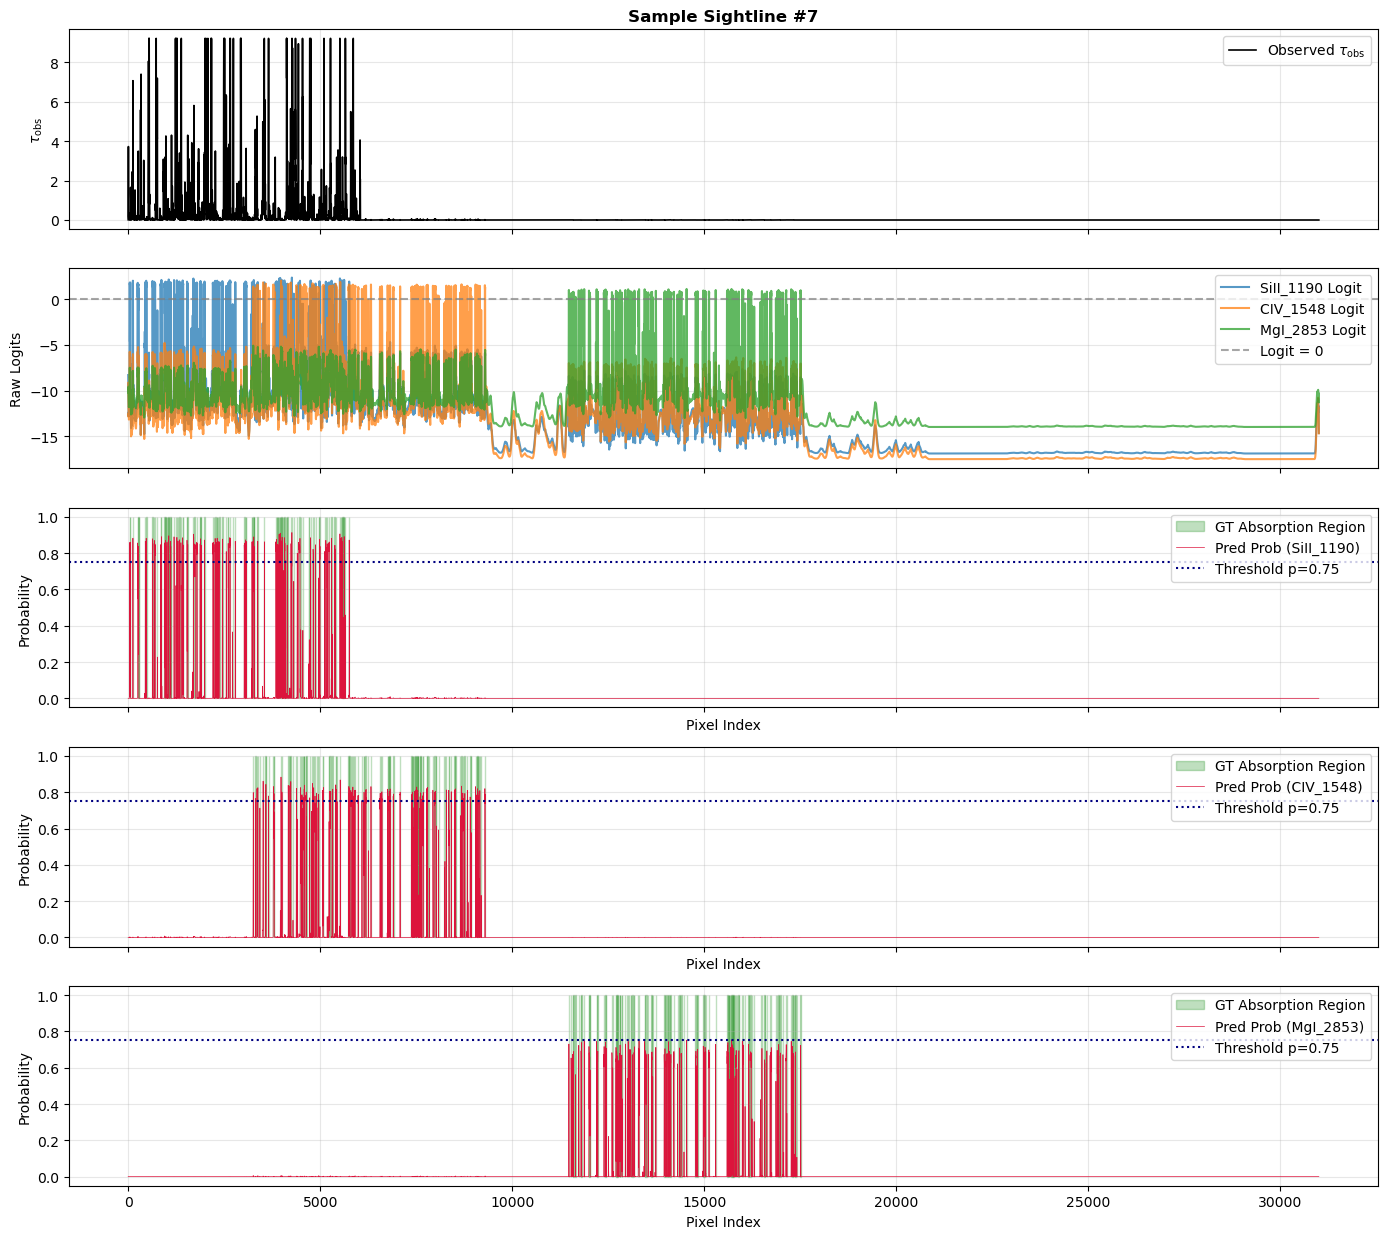

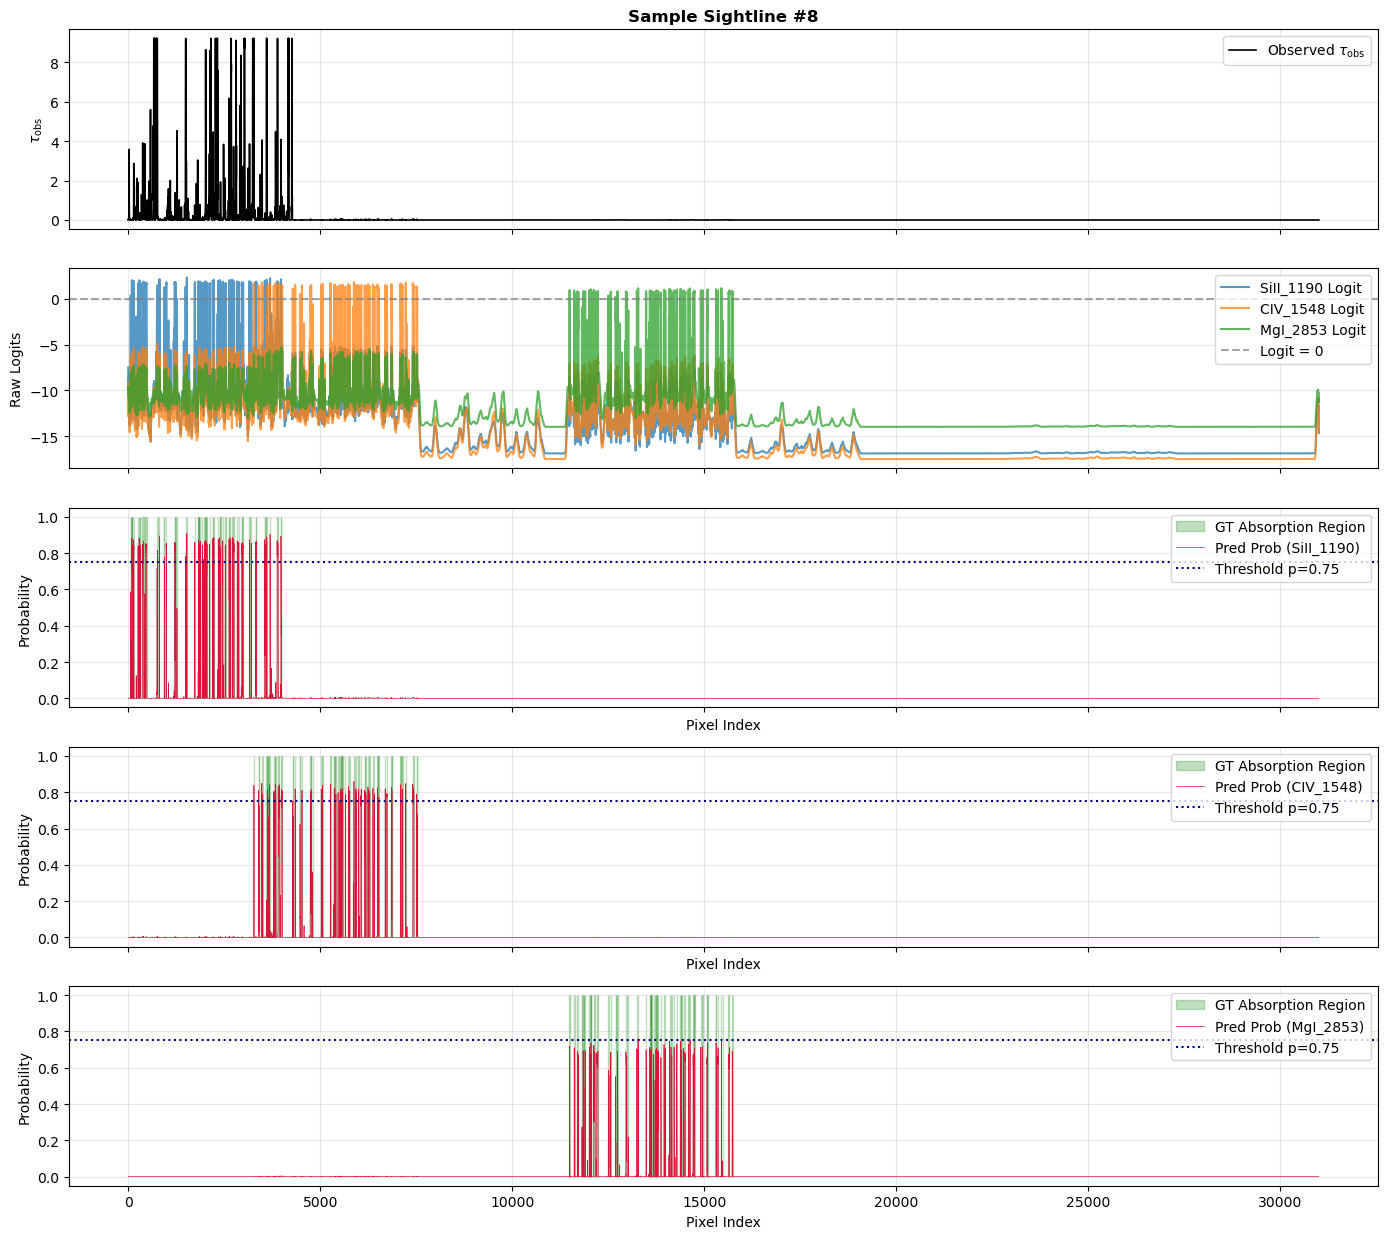

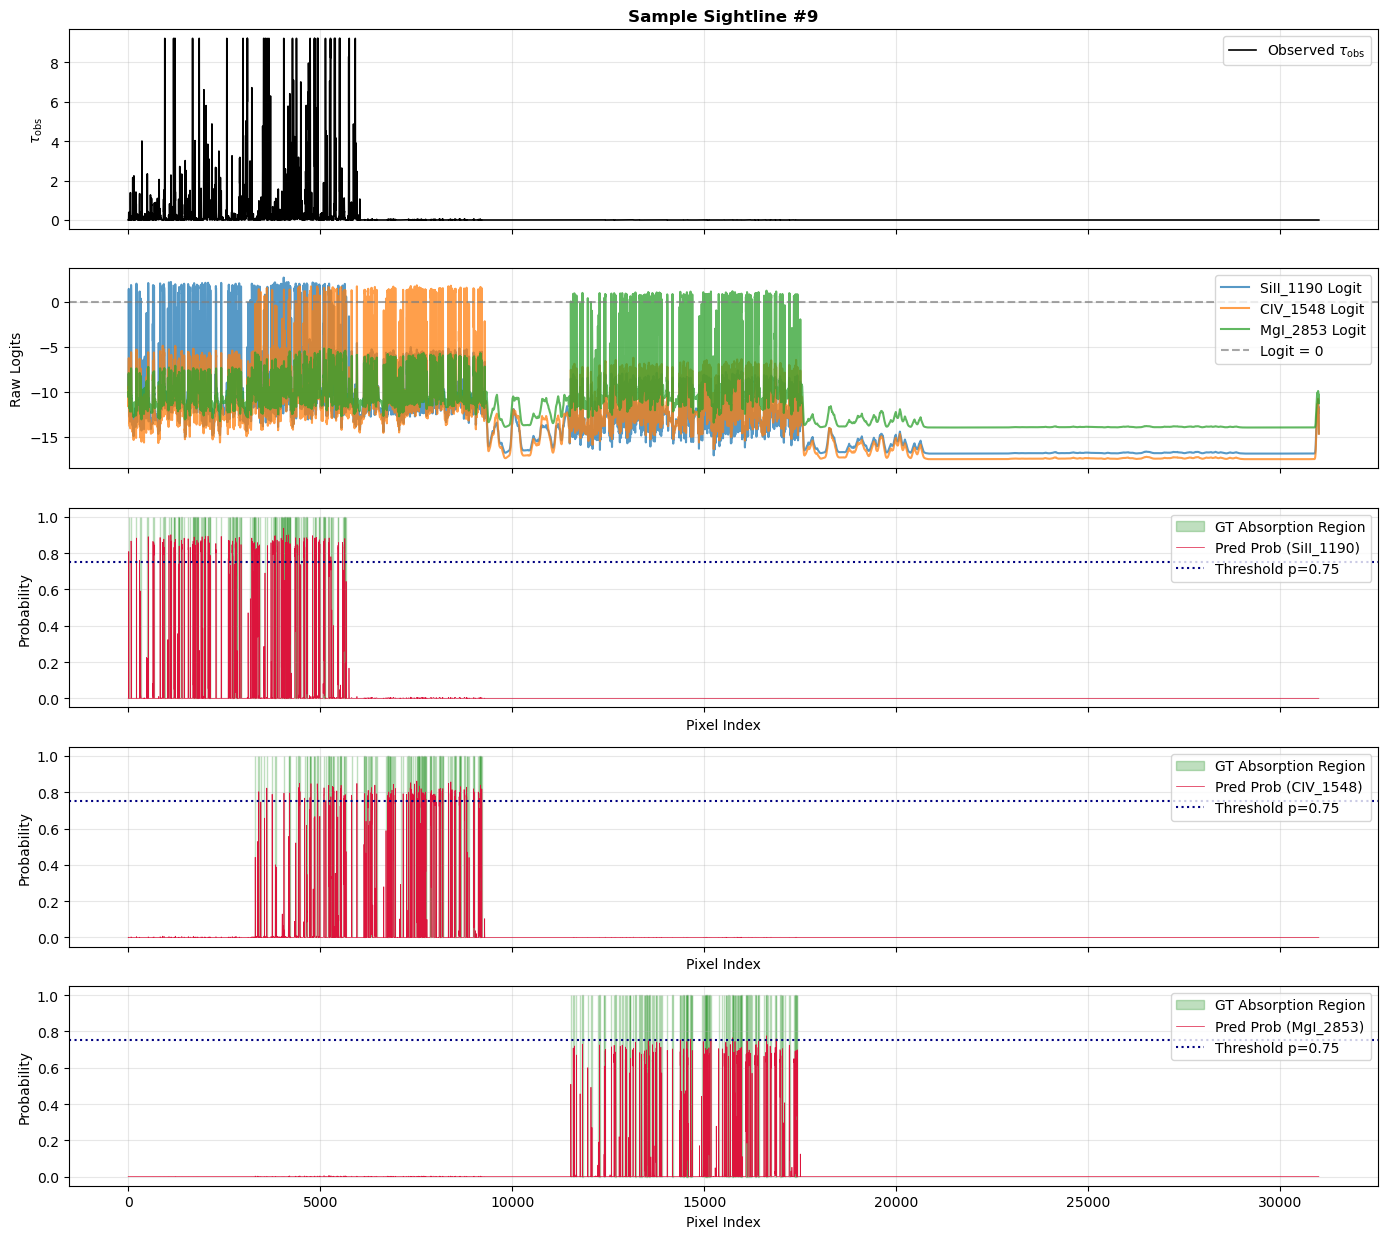

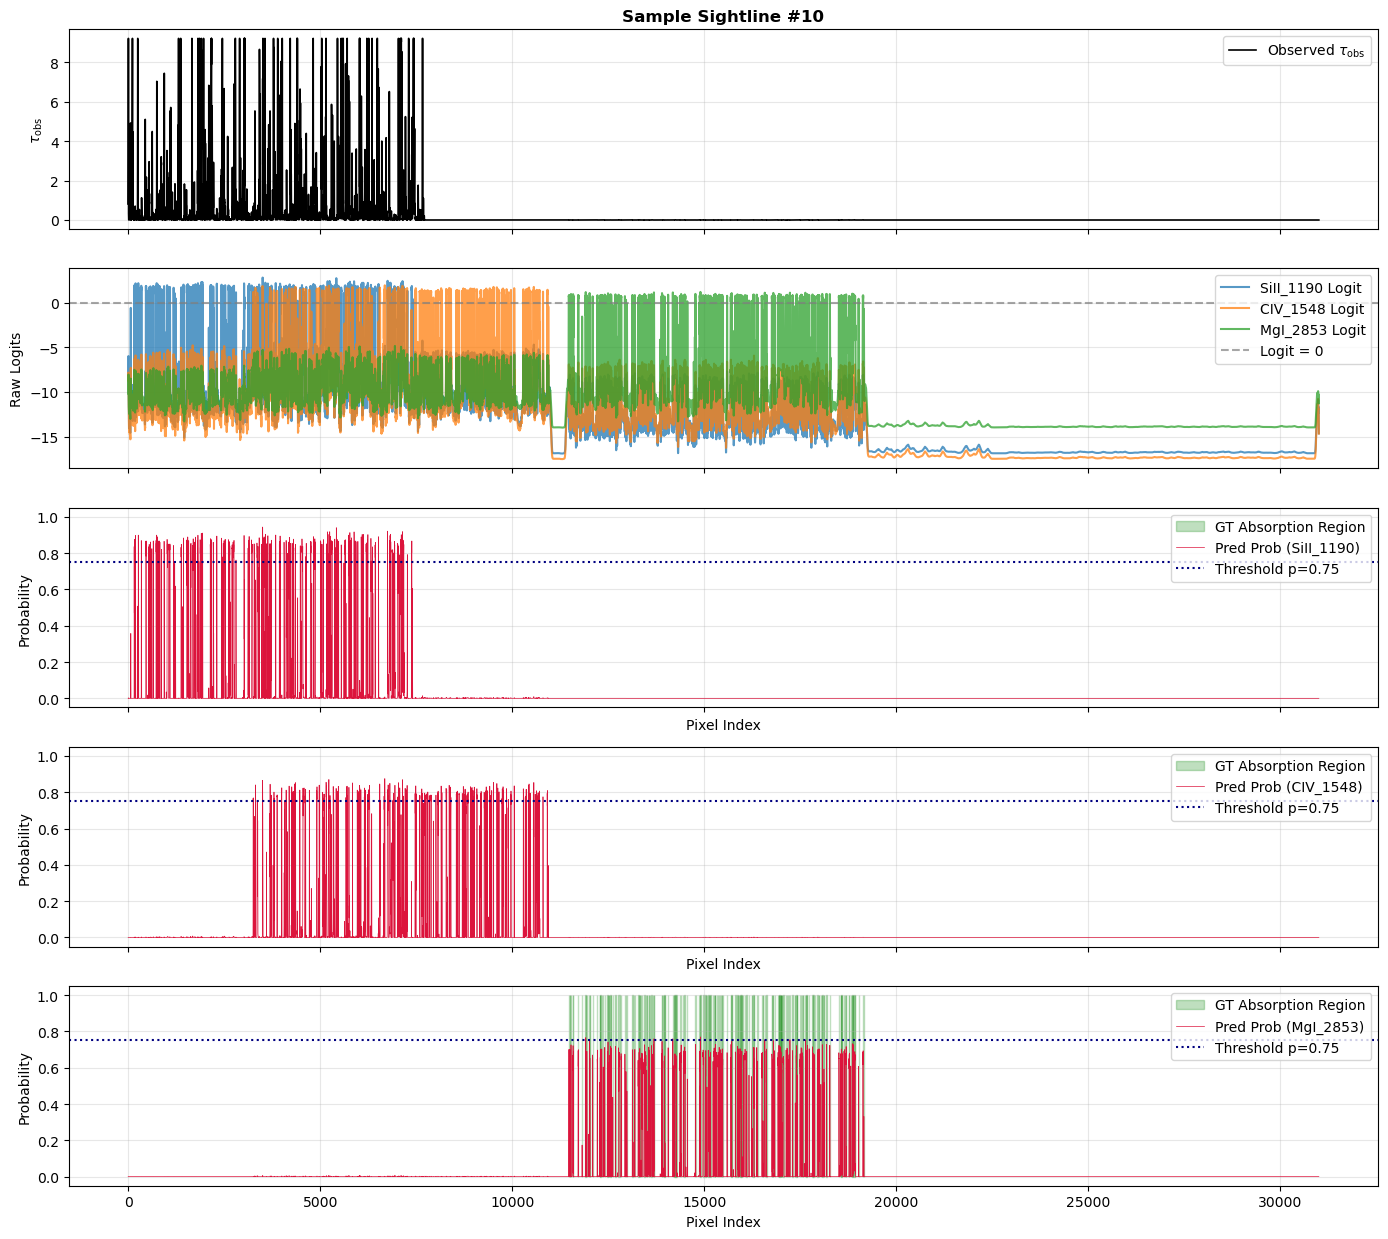

In [48]:
plot_sample_predictions(
    model=model, 
    val_loader=val_loader, 
    device=device, 
    metal_dict=metal_dict, 
    num_samples=10,
    prob_threshold = 0.75
)